# COVID-19: Global Spread and Government Response

Notebook prepares the main analysis and visualizations for our project on COVID-19 spread and government responses.

Two datasets from Google's COVID-19 Open Data:

1. **Epidemiology**
2. **Oxford Government Response**

Our goal is to:
- understand the global development of infections and deaths,
- examine government stringency over time,
- compare selected countries,
- and visualize the global spread of COVID-19 on a world map.

A key preprocessing decision is to use **country-level rows only**.  
The epidemiology dataset contains country, regional, and local rows, and using all of them together would lead to **double-counting**. Therefore, we keep only rows where `location_key` contains no underscore.

## Imports

We begin by importing the libraries needed for data handling, plotting, and country-code conversion.

In [120]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib as mpl
import plotly.express as px

import pycountry

## Load data

The paths below assume the notebook is placed in a folder next to a `data` folder containing:

- `epidemiology.csv`
- `oxford-government-response.csv`

In [121]:
current_dir = Path.cwd()

data_path1 = current_dir.parent / "data" / "epidemiology.csv"
data_path2 = current_dir.parent / "data" / "oxford-government-response.csv"

epi = pd.read_csv(data_path1, parse_dates=["date"], low_memory=False)
gov = pd.read_csv(data_path2, parse_dates=["date"], low_memory=False)

print("Epidemiology shape:", epi.shape)
print("Government response shape:", gov.shape)

Epidemiology shape: (12525825, 10)
Government response shape: (303969, 22)


## Initial inspection

Before cleaning the data, we inspect the basic structure of the datasets:
- number of rows and columns,
- variable names,
- and date coverage.

In [122]:
print("Epidemiology columns:")
print(epi.columns.tolist())

print("\nGovernment response columns:")
print(gov.columns.tolist())

print("\nEpidemiology date range:", epi["date"].min(), "to", epi["date"].max())
print("Government response date range:", gov["date"].min(), "to", gov["date"].max())

Epidemiology columns:
['date', 'location_key', 'new_confirmed', 'new_deceased', 'new_recovered', 'new_tested', 'cumulative_confirmed', 'cumulative_deceased', 'cumulative_recovered', 'cumulative_tested']

Government response columns:
['date', 'location_key', 'school_closing', 'workplace_closing', 'cancel_public_events', 'restrictions_on_gatherings', 'public_transport_closing', 'stay_at_home_requirements', 'restrictions_on_internal_movement', 'international_travel_controls', 'income_support', 'debt_relief', 'fiscal_measures', 'international_support', 'public_information_campaigns', 'testing_policy', 'contact_tracing', 'emergency_investment_in_healthcare', 'investment_in_vaccines', 'facial_coverings', 'vaccination_policy', 'stringency_index']

Epidemiology date range: 2019-12-31 00:00:00 to 2022-12-30 00:00:00
Government response date range: 2020-01-01 00:00:00 to 2022-07-27 00:00:00


## Keep country-level rows only

Both datasets contain multiple geographic levels.  
For example, a country may appear as:

- `DK` → country level
- `US_CA` → state or region level
- `BR_SP_3550308` → local level

To avoid double-counting, we keep only **country-level rows**, defined as rows where `location_key` contains **no underscore**.

In [123]:
epi_country = epi[epi["location_key"].astype(str).str.count("_") == 0].copy()
gov_country = gov[gov["location_key"].astype(str).str.count("_") == 0].copy()

print("Country-level epidemiology shape:", epi_country.shape)
print("Country-level government response shape:", gov_country.shape)

print("Unique country-level keys in epidemiology:", epi_country["location_key"].nunique())
print("Unique country-level keys in government response:", gov_country["location_key"].nunique())

Country-level epidemiology shape: (227879, 10)
Country-level government response shape: (172116, 22)
Unique country-level keys in epidemiology: 232
Unique country-level keys in government response: 186


## Clean daily variables

Daily COVID time series often contain negative values due to retrospective reporting corrections.

For the main visualizations, we clip negative daily values to zero in order to produce cleaner and more interpretable plots.  
This is especially useful for introductory visualizations in the video and website.

In [124]:
for col in ["new_confirmed", "new_deceased", "new_recovered", "new_tested"]:
    if col in epi_country.columns:
        epi_country[col] = epi_country[col].clip(lower=0)

## Country-code conversion for maps

The datasets use ISO-2 style country codes such as:

- `DK`
- `SE`
- `US`
- `BR`

Plotly choropleth maps work best with **ISO-3** codes such as:

- `DNK`
- `SWE`
- `USA`
- `BRA`

We therefore define a converter from ISO-2 to ISO-3 using `pycountry`.  
We also add a manual special case for Kosovo (`XK`).

In [125]:
special_cases = {
    "XK": "XKX",  # Kosovo
}

def iso2_to_iso3(code):
    if pd.isna(code):
        return None
    code = str(code).strip().upper()
    if code in special_cases:
        return special_cases[code]
    country = pycountry.countries.get(alpha_2=code)
    return country.alpha_3 if country else None

## Verify country-code conversion

Before building the world map, check that all country-level rows can be converted successfully.

In [126]:
latest_cases_check = (
    epi_country.sort_values("date")
    .groupby("location_key", as_index=False)["cumulative_confirmed"]
    .last()
    .copy()
)

latest_cases_check["iso3"] = latest_cases_check["location_key"].apply(iso2_to_iso3)

print("Total country rows:", len(latest_cases_check))
print("Mapped to ISO-3:", latest_cases_check["iso3"].notna().sum())
print("Failed mappings:", latest_cases_check["iso3"].isna().sum())

failed_codes = sorted(latest_cases_check.loc[latest_cases_check["iso3"].isna(), "location_key"].unique())
print("Failed codes:", failed_codes)

Total country rows: 232
Mapped to ISO-3: 232
Failed mappings: 0
Failed codes: []


## Visual style

We use a consistent visual style across all charts to create a coherent visual identity across the notebook and the final project.

Our color palette is:

- dark slate background: `#4C616C`
- light text: `#F0F0F0`
- soft grid lines: `#6F838D`
- deep blue for infections and case-focused visuals: `#202983`
- dark red for deaths and policy-response overlays: `#9D0011`
- light fill for softer shaded areas: `#D8E0E4`

This palette is used consistently in both static and interactive figures.

In [127]:
BG = "#4C616C"
TEXT = "#F0F0F0"
GRID = "#6F838D"
BLUE = "#202983"
RED = "#9D0011"
LIGHT_FILL = "#D8E0E4"

mpl.rcParams["figure.facecolor"] = BG
mpl.rcParams["axes.facecolor"] = BG
mpl.rcParams["savefig.facecolor"] = BG
mpl.rcParams["axes.edgecolor"] = TEXT
mpl.rcParams["axes.labelcolor"] = TEXT
mpl.rcParams["xtick.color"] = TEXT
mpl.rcParams["ytick.color"] = TEXT
mpl.rcParams["text.color"] = TEXT
mpl.rcParams["axes.titleweight"] = "bold"
mpl.rcParams["axes.titlesize"] = 18
mpl.rcParams["axes.labelsize"] = 12
mpl.rcParams["font.size"] = 11
mpl.rcParams["grid.color"] = GRID
mpl.rcParams["grid.alpha"] = 0.25
mpl.rcParams["axes.grid"] = True

## Global infections over time

This figure shows the global number of new confirmed COVID-19 cases over time, aggregated across country-level rows only.

We smooth the daily data using a **7-day rolling average** in order to reduce reporting noise and make the major global waves easier to see.

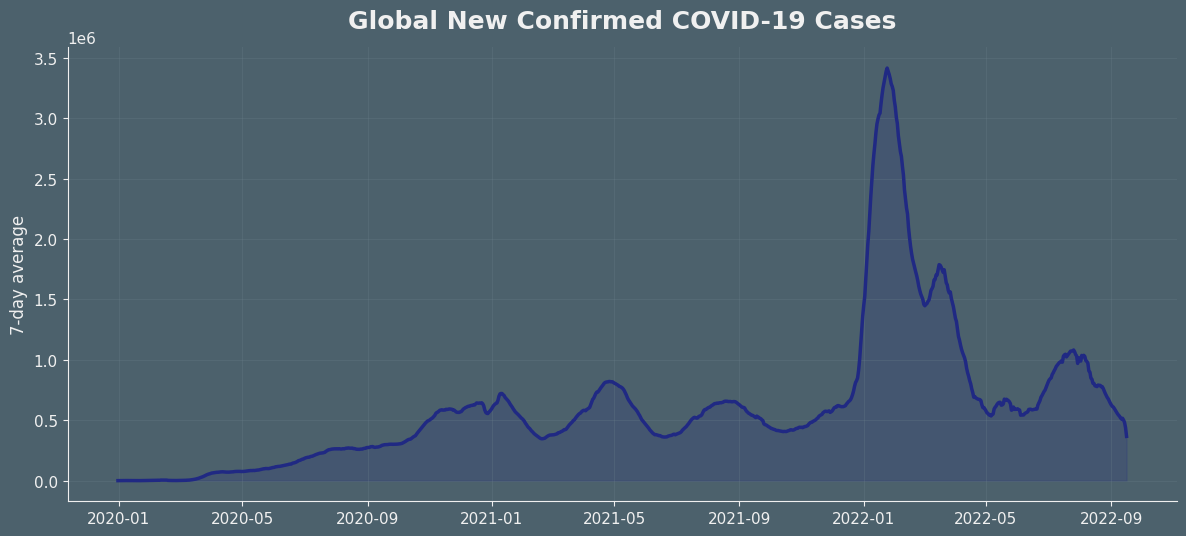

In [128]:
global_cases = (
    epi_country.groupby("date")["new_confirmed"]
    .sum()
    .rolling(7, min_periods=1)
    .mean()
)

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.plot(global_cases.index, global_cases.values, color=BLUE, linewidth=2.5)
ax.fill_between(global_cases.index, global_cases.values, color=BLUE, alpha=0.18)

ax.set_title("Global New Confirmed COVID-19 Cases", pad=14)
ax.set_ylabel("7-day average")
ax.set_xlabel("")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Global deaths over time

This figure shows the global number of new COVID-19 deaths over time, again using country-level rows only and a 7-day rolling average.

Compared with the infections plot, this figure emphasizes the severity and timing of the pandemic's major waves.

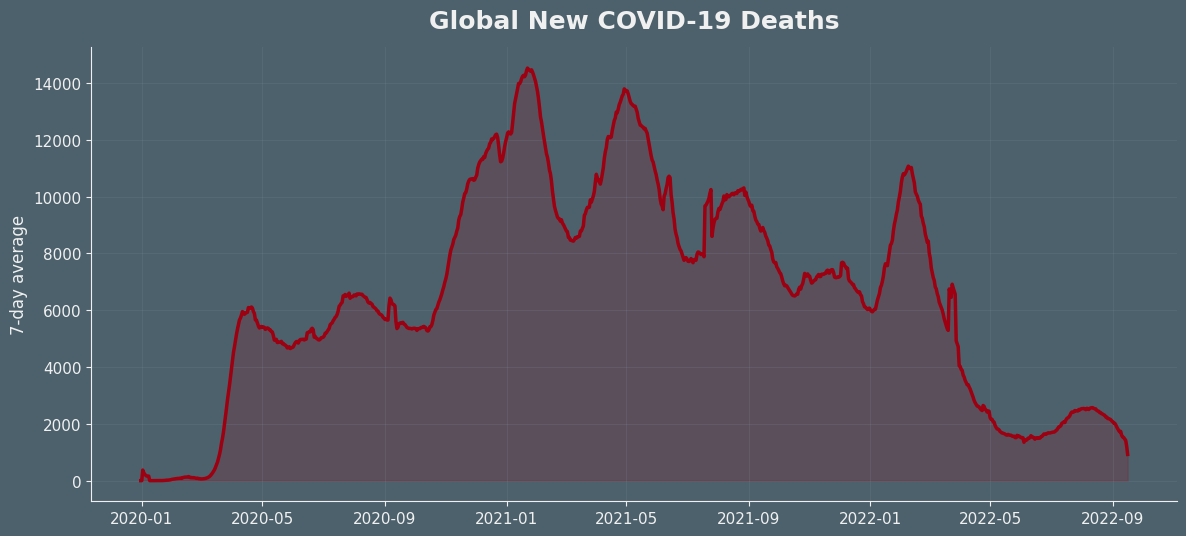

In [129]:
global_deaths = (
    epi_country.groupby("date")["new_deceased"]
    .sum()
    .rolling(7, min_periods=1)
    .mean()
)

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.plot(global_deaths.index, global_deaths.values, color=RED, linewidth=2.5)
ax.fill_between(global_deaths.index, global_deaths.values, color=RED, alpha=0.18)

ax.set_title("Global New COVID-19 Deaths", pad=14)
ax.set_ylabel("7-day average")
ax.set_xlabel("")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Average global government stringency over time

This figure shows the average Oxford government stringency index across countries over time.

The stringency index summarizes policy responses such as:
- school closures,
- workplace closures,
- gathering restrictions,
- stay-at-home requirements,
- and travel controls.

This gives a global overview of how restrictive government responses were on average during different phases of the pandemic.

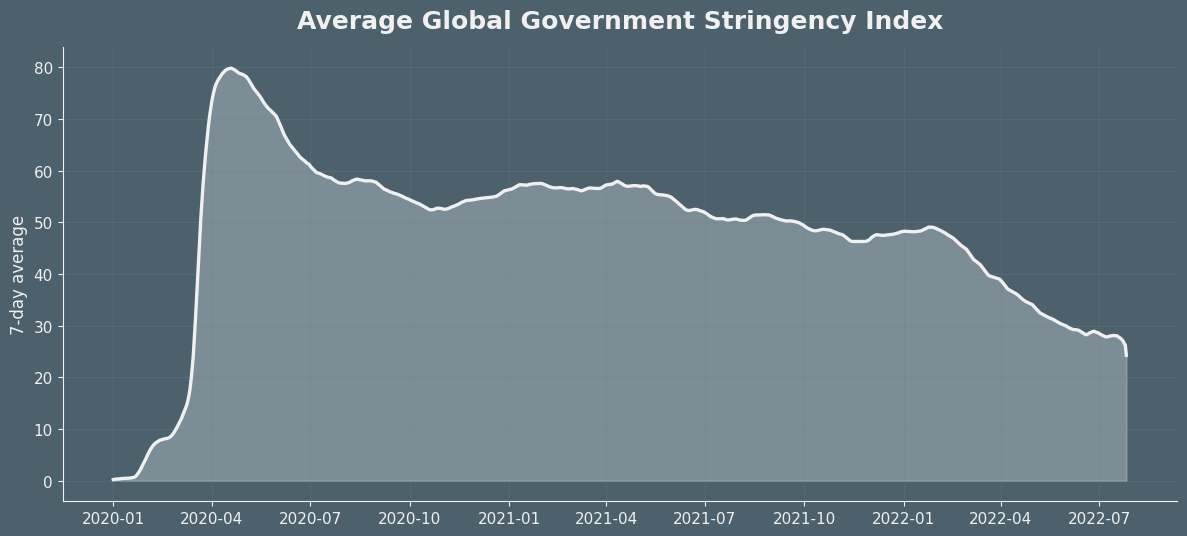

In [130]:
global_stringency = (
    gov_country.groupby("date")["stringency_index"]
    .mean()
    .rolling(7, min_periods=1)
    .mean()
)

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.plot(global_stringency.index, global_stringency.values, color=TEXT, linewidth=2.4)
ax.fill_between(global_stringency.index, global_stringency.values, color=LIGHT_FILL, alpha=0.35)

ax.set_title("Average Global Government Stringency Index", pad=14)
ax.set_ylabel("7-day average")
ax.set_xlabel("")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Summary totals from the epidemiology dataset

We calculate dataset-wide summary values using the latest country-level cumulative totals:

- total confirmed infections,
- total deaths,
- total recovered,
- and number of affected countries.

Because the dataset includes multiple dates, we first take the **latest cumulative row for each country**.

In [131]:
latest_totals = (
    epi_country.sort_values(["location_key", "date"])
    .groupby("location_key", as_index=False)[
        ["cumulative_confirmed", "cumulative_deceased", "cumulative_recovered"]
    ]
    .last()
    .fillna(0)
)

total_infected = latest_totals["cumulative_confirmed"].sum()
total_deaths = latest_totals["cumulative_deceased"].sum()
total_recovered = latest_totals["cumulative_recovered"].sum()
countries_affected = (latest_totals["cumulative_confirmed"] > 0).sum()

print("Total infected:", f"{int(total_infected):,}")
print("Total countries affected:", f"{int(countries_affected):,}")
print("Total deaths:", f"{int(total_deaths):,}")
print("Total recovered:", f"{int(total_recovered):,}")

Total infected: 606,525,388
Total countries affected: 227
Total deaths: 6,167,100
Total recovered: 327,308,101


## World map of total infections

This choropleth map shows total confirmed COVID-19 infections by country.

Important notes:
- only country-level rows are used,
- ISO-2 country codes are converted to ISO-3,
- and the color range is slightly clipped at the upper end to improve contrast among mid-sized countries.

Countries with zero infections are shown in light gray, while countries with nonzero infections are shown in shades of red.

In [132]:
BG_DARK = "#4C4153"
LAND_LIGHT = "#F0F0F0"
TEXT_LIGHT = "#F0F0F0"
BORDER_SOFT = "#D9E0E4"

color_scale_red_modern = [
    [0.00, "#F3C7CC"],
    [0.20, "#E99AA3"],
    [0.40, "#DB6672"],
    [0.60, "#C92F3C"],
    [0.80, "#9D0011"],
    [1.00, "#2A0004"],
]

latest_cases = (
    epi_country.sort_values("date")
    .groupby("location_key", as_index=False)["cumulative_confirmed"]
    .last()
    .copy()
)

latest_cases["iso3"] = latest_cases["location_key"].apply(iso2_to_iso3)
latest_cases["cumulative_confirmed"] = latest_cases["cumulative_confirmed"].fillna(0)

zero_cases = latest_cases[latest_cases["cumulative_confirmed"] == 0].copy()
nonzero_cases = latest_cases[latest_cases["cumulative_confirmed"] > 0].copy()

nonzero_cases["log_cases"] = np.log10(nonzero_cases["cumulative_confirmed"] + 1)

zmin = nonzero_cases["log_cases"].min()
zmax = nonzero_cases["log_cases"].quantile(0.98)

fig = px.choropleth(
    nonzero_cases,
    locations="iso3",
    color="log_cases",
    hover_name="location_key",
    color_continuous_scale=color_scale_red_modern,
    projection="natural earth",
    title="World Map: Total COVID-19 Infections by Country",
    range_color=(zmin, zmax),
)

if len(zero_cases) > 0:
    fig.add_choropleth(
        locations=zero_cases["iso3"],
        z=[0] * len(zero_cases),
        colorscale=[[0, LAND_LIGHT], [1, LAND_LIGHT]],
        showscale=False,
        hovertext=zero_cases["location_key"],
        hoverinfo="text",
        marker_line_color=BORDER_SOFT,
        marker_line_width=0.6,
    )

fig.update_layout(
    paper_bgcolor=BG_DARK,
    plot_bgcolor=BG_DARK,
    font=dict(color=TEXT_LIGHT, size=14),
    title=dict(
        text="World Map: Total COVID-19 Infections by Country",
        x=0.03,
        xanchor="left",
        font=dict(size=30, color=TEXT_LIGHT)
    ),
    coloraxis_colorbar=dict(
        title=dict(
            text="log10(infections + 1)",
            font=dict(color=TEXT_LIGHT)
        ),
        tickfont=dict(color=TEXT_LIGHT),
        thickness=20,
        len=0.80
    ),
    margin=dict(l=0, r=0, t=70, b=0),
)

fig.update_geos(
    showframe=False,
    showcoastlines=False,
    showcountries=True,
    countrycolor=BORDER_SOFT,
    countrywidth=0.6,
    showland=True,
    landcolor=LAND_LIGHT,
    showocean=True,
    oceancolor=BG_DARK,
    bgcolor=BG_DARK,
)
fig.write_html("total_infections_world.html", include_plotlyjs='cdn')

fig.show()

## World map of total deaths

This map uses the same visual style as the infections map, but colors countries by total COVID-19 deaths instead of total confirmed infections.

This allows us to compare spread and mortality side by side.

In [133]:
latest_deaths = (
    epi_country.sort_values("date")
    .groupby("location_key", as_index=False)["cumulative_deceased"]
    .last()
    .copy()
)

latest_deaths["iso3"] = latest_deaths["location_key"].apply(iso2_to_iso3)
latest_deaths["cumulative_deceased"] = latest_deaths["cumulative_deceased"].fillna(0)

zero_deaths = latest_deaths[latest_deaths["cumulative_deceased"] == 0].copy()
nonzero_deaths = latest_deaths[latest_deaths["cumulative_deceased"] > 0].copy()

nonzero_deaths["log_deaths"] = np.log10(nonzero_deaths["cumulative_deceased"] + 1)

zmin = nonzero_deaths["log_deaths"].min()
zmax = nonzero_deaths["log_deaths"].quantile(0.98)

fig = px.choropleth(
    nonzero_deaths,
    locations="iso3",
    color="log_deaths",
    hover_name="location_key",
    color_continuous_scale=color_scale_red_modern,
    projection="natural earth",
    title="World Map: Total COVID-19 Deaths by Country",
    range_color=(zmin, zmax),
)

if len(zero_deaths) > 0:
    fig.add_choropleth(
        locations=zero_deaths["iso3"],
        z=[0] * len(zero_deaths),
        colorscale=[[0, LAND_LIGHT], [1, LAND_LIGHT]],
        showscale=False,
        hovertext=zero_deaths["location_key"],
        hoverinfo="text",
        marker_line_color=BORDER_SOFT,
        marker_line_width=0.6,
    )

fig.update_layout(
    paper_bgcolor=BG_DARK,
    plot_bgcolor=BG_DARK,
    font=dict(color=TEXT_LIGHT, size=14),
    title=dict(
        text="World Map: Total COVID-19 Deaths by Country",
        x=0.03,
        xanchor="left",
        font=dict(size=30, color=TEXT_LIGHT)
    ),
    coloraxis_colorbar=dict(
        title=dict(
            text="log10(deaths + 1)",
            font=dict(color=TEXT_LIGHT)
        ),
        tickfont=dict(color=TEXT_LIGHT),
        thickness=20,
        len=0.80
    ),
    margin=dict(l=0, r=0, t=70, b=0),
)

fig.update_geos(
    showframe=False,
    showcoastlines=False,
    showcountries=True,
    countrycolor=BORDER_SOFT,
    countrywidth=0.6,
    showland=True,
    landcolor=LAND_LIGHT,
    showocean=True,
    oceancolor=BG_DARK,
    bgcolor=BG_DARK,
)
fig.write_html("total_deaths_world.html", include_plotlyjs='cdn')

fig.show()

## Selected countries for comparison

To create a more focused comparison, we now examine three European countries:

- Denmark (`DK`)
- Germany (`DE`)
- Great Britain / United Kingdom (`GB`)

These countries are geographically closer and more comparable than the earlier global set.  
This makes it easier to study differences in COVID-19 development and government response in a more controlled regional context.

In [134]:
selected_countries = ["DK", "DE", "GB"]

country_names = {
    "DK": "Denmark",
    "DE": "Germany",
    "GB": "Great Britain"
}

COUNTRY_COLORS = {
    "DK": "#F87CFF",
    "DE": "#77CBFF",
    "GB": "#71FEF0",
}

## Build comparison tables

We prepare cleaned country-level time series for the selected countries.

For the epidemiology data we compute:
- 7-day average confirmed cases
- 7-day average deaths

For the Oxford dataset we compute:
- 7-day average stringency index

These smoothed measures reduce day-to-day reporting noise and make country comparisons easier to interpret.

In [135]:
epi_compare = (
    epi_country[epi_country["location_key"].isin(selected_countries)]
    .copy()
    .sort_values(["location_key", "date"])
)

gov_compare = (
    gov_country[gov_country["location_key"].isin(selected_countries)]
    .copy()
    .sort_values(["location_key", "date"])
)

epi_compare["new_confirmed_7d"] = (
    epi_compare.groupby("location_key")["new_confirmed"]
    .transform(lambda s: s.rolling(7, min_periods=1).mean())
)

epi_compare["new_deceased_7d"] = (
    epi_compare.groupby("location_key")["new_deceased"]
    .transform(lambda s: s.rolling(7, min_periods=1).mean())
)

gov_compare["stringency_7d"] = (
    gov_compare.groupby("location_key")["stringency_index"]
    .transform(lambda s: s.rolling(7, min_periods=1).mean())
)

epi_compare["country"] = epi_compare["location_key"].map(country_names)
gov_compare["country"] = gov_compare["location_key"].map(country_names)

print(epi_compare.shape)
print(gov_compare.shape)

(2961, 13)
(2787, 24)


## Static comparison: new confirmed cases

This figure compares Denmark, Germany, and Great Britain using 7-day average confirmed cases.

Because all three countries are shown in the same figure, direct comparison is possible across:
- timing of waves,
- height of peaks,
- and overall development over time.

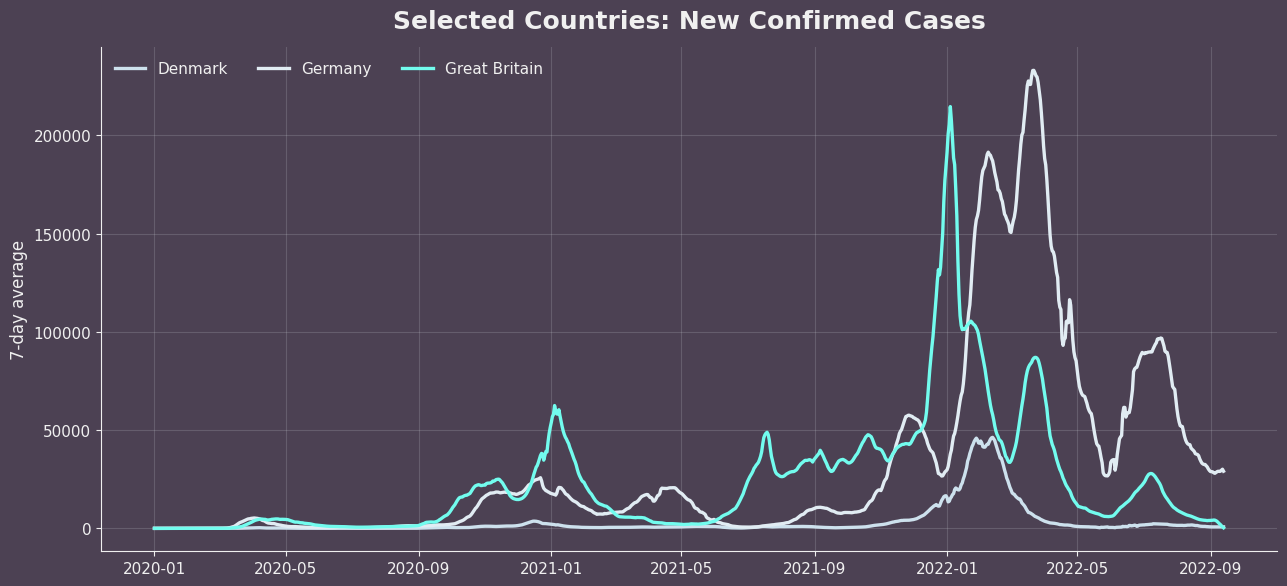

In [183]:
fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('#4c4153')
ax.set_facecolor('#4c4153')

for code in selected_countries:
    df_plot = epi_compare[epi_compare["location_key"] == code]
    ax.plot(
        df_plot["date"],
        df_plot["new_confirmed_7d"],
        label=country_names[code],
        linewidth=2.4,
        color=COUNTRY_COLORS[code]
    )

ax.set_title("Selected Countries: New Confirmed Cases", pad=14)
ax.set_ylabel("7-day average")
ax.set_xlabel("")
ax.legend(frameon=False, ncol=3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Static comparison: new deaths

This figure compares Denmark, Germany, and Great Britain using 7-day average COVID-19 deaths.

This is useful for comparing pandemic severity and the timing of death waves across the three countries.

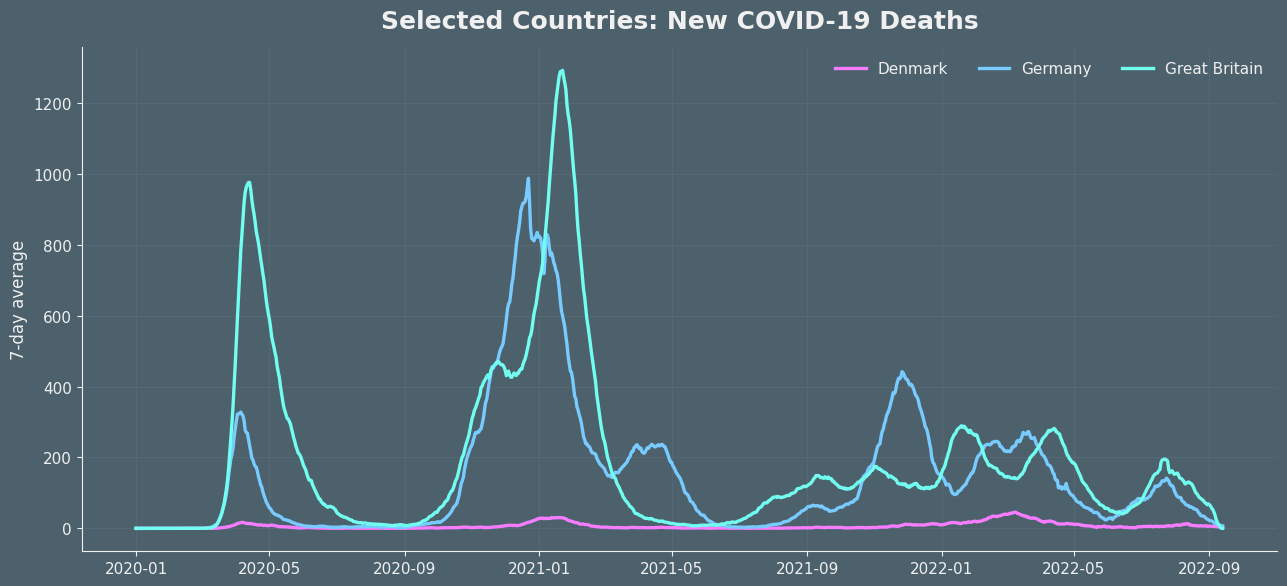

In [137]:
fig, ax = plt.subplots(figsize=(13, 6))

for code in selected_countries:
    df_plot = epi_compare[epi_compare["location_key"] == code]
    ax.plot(
        df_plot["date"],
        df_plot["new_deceased_7d"],
        label=country_names[code],
        linewidth=2.4,
        color=COUNTRY_COLORS[code]
    )

ax.set_title("Selected Countries: New COVID-19 Deaths", pad=14)
ax.set_ylabel("7-day average")
ax.set_xlabel("")
ax.legend(frameon=False, ncol=3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Static comparison: government stringency

This figure compares the Oxford government stringency index across Denmark, Germany, and Great Britain.

The chart helps identify differences in:
- timing of restrictions,
- intensity of responses,
- and how long strict measures remained in place.

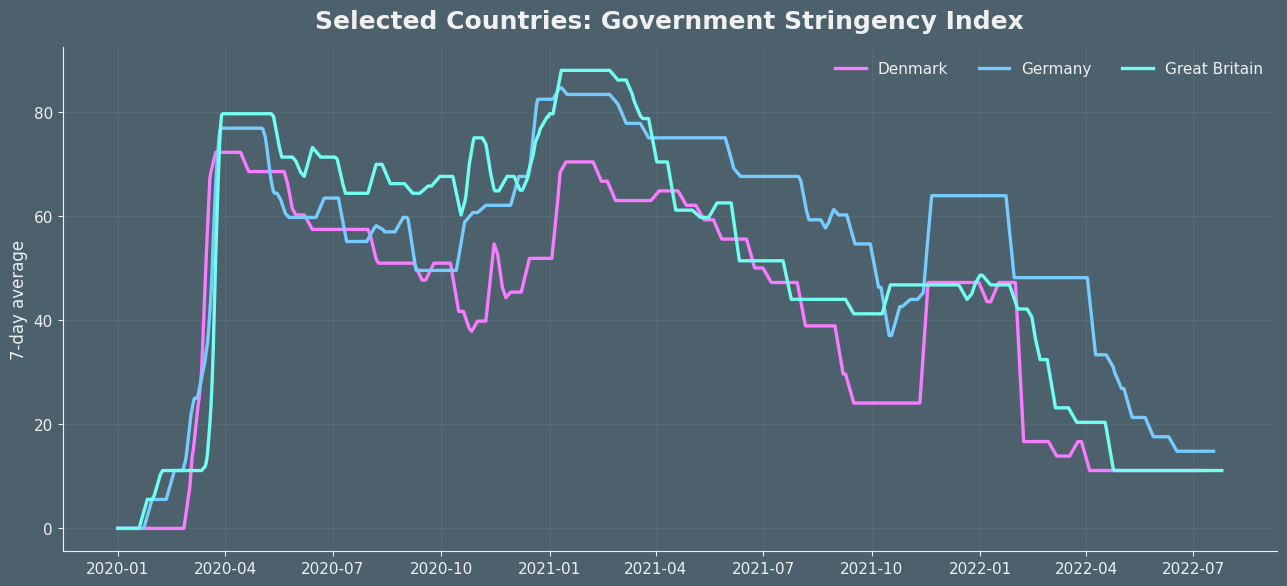

In [138]:
fig, ax = plt.subplots(figsize=(13, 6))

for code in selected_countries:
    df_plot = gov_compare[gov_compare["location_key"] == code]
    ax.plot(
        df_plot["date"],
        df_plot["stringency_7d"],
        label=country_names[code],
        linewidth=2.4,
        color=COUNTRY_COLORS[code]
    )

ax.set_title("Selected Countries: Government Stringency Index", pad=14)
ax.set_ylabel("7-day average")
ax.set_xlabel("")
ax.legend(frameon=False, ncol=3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Small multiples: cases by country

This figure shows each country in its own panel, while keeping the **same x-axis and y-axis scale across all panels**.

This is important because it allows fair comparison without visually exaggerating smaller or larger countries.

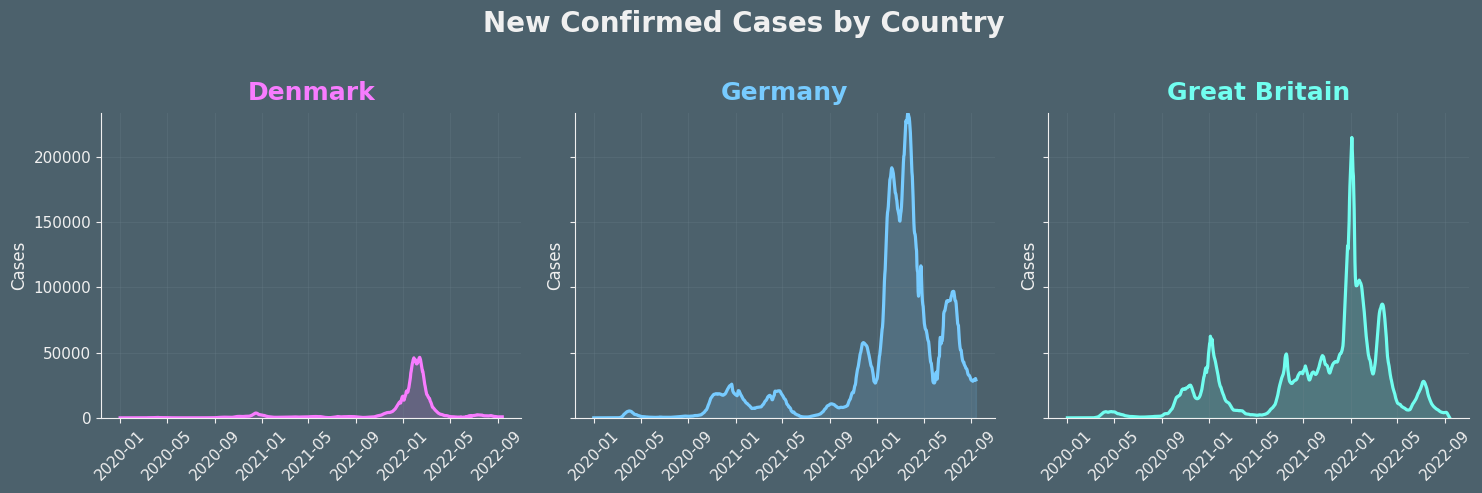

In [139]:
# Shared y-axis maximum for fair comparison
cases_ymax = epi_compare["new_confirmed_7d"].max()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharex=True, sharey=True)

for ax, code in zip(axes, selected_countries):
    df_plot = epi_compare[epi_compare["location_key"] == code]
    c = COUNTRY_COLORS[code]

    ax.plot(df_plot["date"], df_plot["new_confirmed_7d"], color=c, linewidth=2.3)
    ax.fill_between(df_plot["date"], df_plot["new_confirmed_7d"], color=c, alpha=0.14)

    ax.set_title(country_names[code], color=c, pad=10)
    ax.tick_params(axis='x', labelrotation=45)
    ax.set_ylim(0, cases_ymax)
    ax.set_ylabel("Cases")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle("New Confirmed Cases by Country", fontsize=20, fontweight="bold", y=1.02, color=TEXT)
plt.tight_layout()
plt.show()

## Small multiples: deaths by country

Each country is shown in its own panel, again with **shared x-axis and y-axis scales**.

This makes it possible to compare the relative size and timing of death waves fairly.

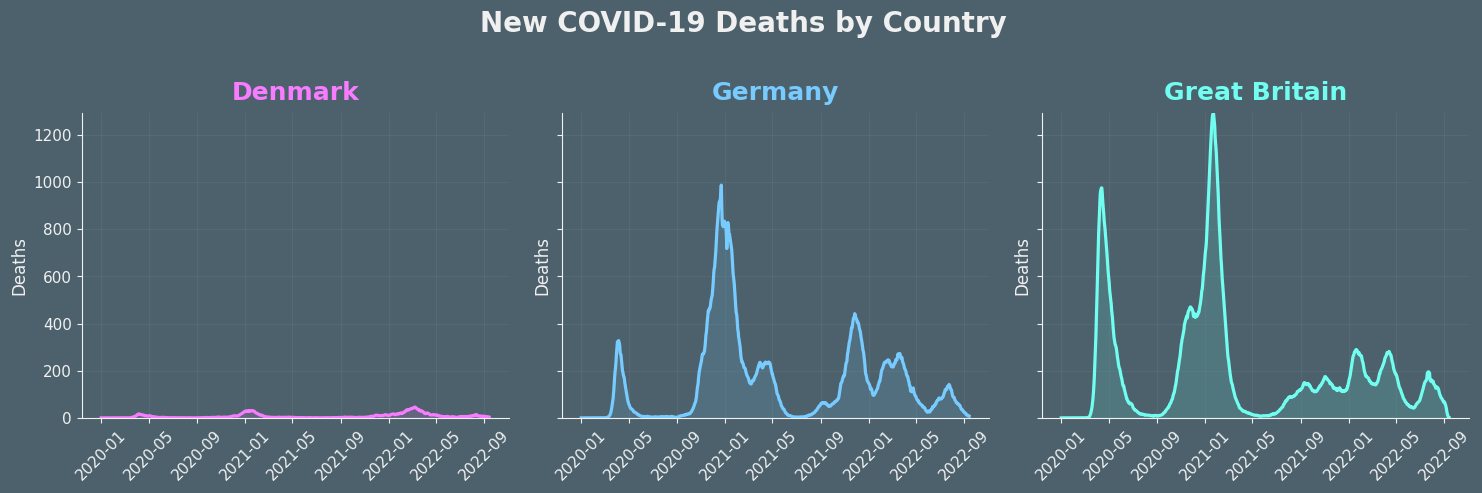

In [140]:
deaths_ymax = epi_compare["new_deceased_7d"].max()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharex=True, sharey=True)

for ax, code in zip(axes, selected_countries):
    df_plot = epi_compare[epi_compare["location_key"] == code]
    c = COUNTRY_COLORS[code]

    ax.plot(df_plot["date"], df_plot["new_deceased_7d"], color=c, linewidth=2.3)
    ax.fill_between(df_plot["date"], df_plot["new_deceased_7d"], color=c, alpha=0.14)

    ax.set_title(country_names[code], color=c, pad=10)
    ax.tick_params(axis='x', labelrotation=45)
    ax.set_ylim(0, deaths_ymax)
    ax.set_ylabel("Deaths")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle("New COVID-19 Deaths by Country", fontsize=20, fontweight="bold", y=1.02, color=TEXT)
plt.tight_layout()
plt.show()

## Small multiples: government stringency by country

This figure shows each country's government stringency separately, but using the same axis scale across panels.

Because the Oxford stringency index is bounded, comparable scales are especially important for correct interpretation.

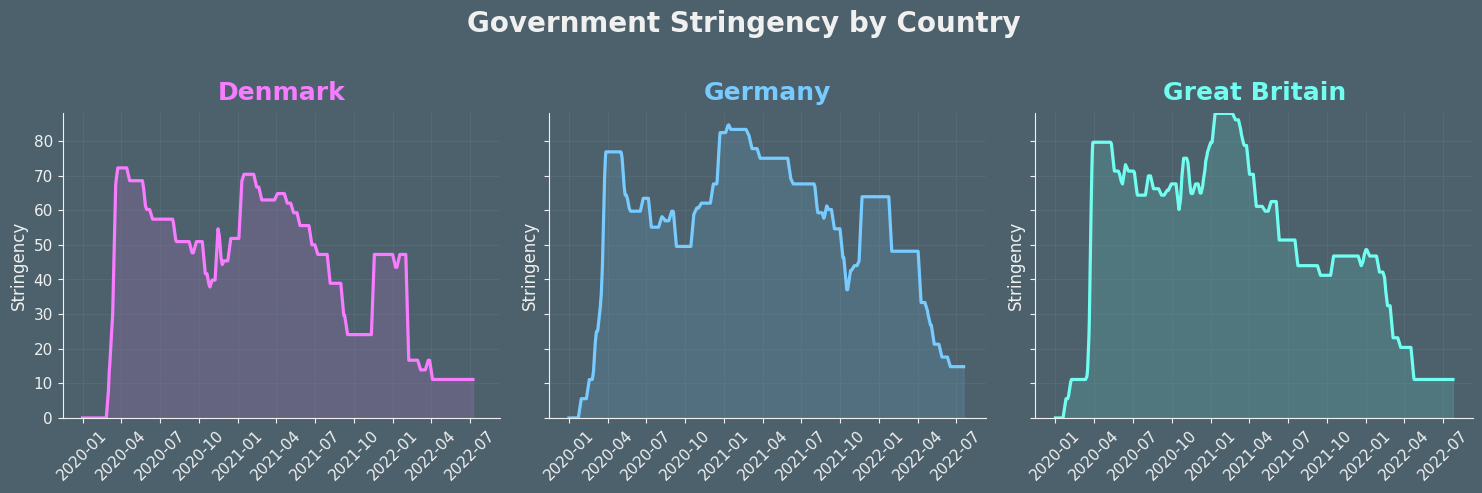

In [141]:
stringency_ymax = gov_compare["stringency_7d"].max()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharex=True, sharey=True)

for ax, code in zip(axes, selected_countries):
    df_plot = gov_compare[gov_compare["location_key"] == code]
    c = COUNTRY_COLORS[code]

    ax.plot(df_plot["date"], df_plot["stringency_7d"], color=c, linewidth=2.3)
    ax.fill_between(df_plot["date"], df_plot["stringency_7d"], color=c, alpha=0.14)

    ax.set_title(country_names[code], color=c, pad=10)
    ax.tick_params(axis='x', labelrotation=45)    
    ax.set_ylim(0, stringency_ymax)
    ax.set_ylabel("Stringency")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle("Government Stringency by Country", fontsize=20, fontweight="bold", y=1.02, color=TEXT)
plt.tight_layout()
plt.show()

## Cases and government response by country

Each panel shows:
- new confirmed cases on the left axis,
- government stringency on the right axis.

The **left axis is shared across all countries**, which makes the case comparison fair.
The **right axis is also shared**, which keeps stringency directly comparable.

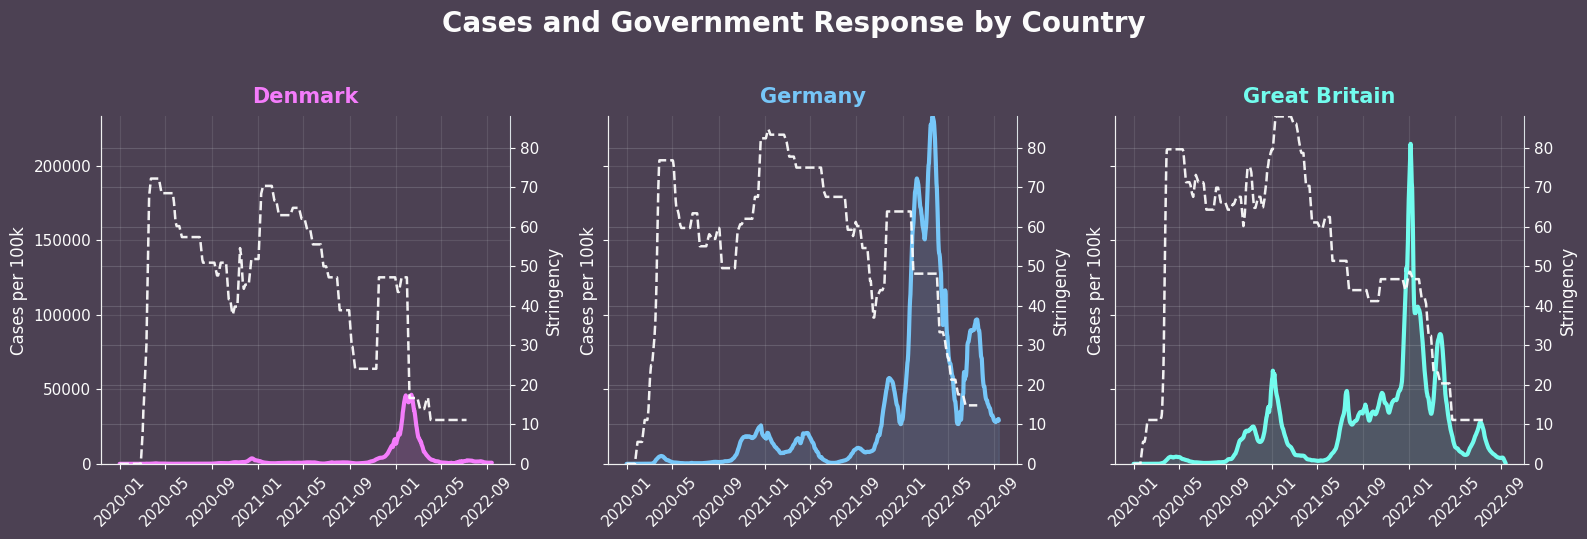

In [189]:
BG_DARK = "#4C4153"
TEXT_LIGHT = "#FCFCFC"
BORDER_SOFT = "#D9E0E4"

COUNTRY_COLORS = {
    "DK": "#F47CFB",   # Denmark
    "DE": "#76C6F8",   # Germany
    "GB": "#72FCEE",   # Great Britain
}

cases_ymax = epi_compare["new_confirmed_7d"].max()
stringency_ymax = gov_compare["stringency_7d"].max()

fig, axes = plt.subplots(1, 3, figsize=(16, 5.2), sharex=True, sharey=True)
fig.patch.set_facecolor(BG_DARK)

for ax, code in zip(axes, selected_countries):
    epi_plot = epi_compare[epi_compare["location_key"] == code].sort_values("date")
    gov_plot = gov_compare[gov_compare["location_key"] == code].sort_values("date")
    c = COUNTRY_COLORS[code]

    ax.set_facecolor(BG_DARK)

    ax.plot(
        epi_plot["date"],
        epi_plot["new_confirmed_7d"],
        color=c,
        linewidth=3.0,
        solid_capstyle="round"
    )

    fill_alpha = 0.12
    ax.fill_between(
        epi_plot["date"],
        epi_plot["new_confirmed_7d"],
        color=c,
        alpha=fill_alpha
    )

    ax.set_title(
        country_names[code],
        color=c,
        pad=10,
        fontsize=15,
        fontweight="bold"
    )
    ax.set_ylabel("Cases per 100k", color=TEXT_LIGHT)
    ax.set_ylim(0, cases_ymax)

    ax.tick_params(axis="x", colors=TEXT_LIGHT, labelrotation=45)
    ax.tick_params(axis="y", colors=TEXT_LIGHT)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(BORDER_SOFT)
    ax.spines["bottom"].set_color(BORDER_SOFT)
    ax.grid(True, color=BORDER_SOFT, alpha=0.12)

    ax2 = ax.twinx()
    ax2.plot(
        gov_plot["date"],
        gov_plot["stringency_7d"],
        color=TEXT_LIGHT,
        linestyle="--",
        linewidth=1.8,
        alpha=0.95
    )
    ax2.set_ylim(0, stringency_ymax)
    ax2.set_ylabel("Stringency", color=TEXT_LIGHT)
    ax2.tick_params(axis="y", colors=TEXT_LIGHT)
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_color(BORDER_SOFT)
    ax2.set_facecolor(BG_DARK)

fig.suptitle(
    "Cases and Government Response by Country",
    fontsize=20,
    fontweight="bold",
    y=1.03,
    color=TEXT_LIGHT
)

plt.tight_layout()
plt.show()

## Interactive comparison: cases over time

This interactive figure allows the user to:
- zoom into specific periods,
- toggle countries on and off,
- and inspect exact values by hovering.

This is especially useful for identifying the timing and size of different waves.

In [143]:
import plotly.express as px

fig = px.line(
    epi_compare,
    x="date",
    y="new_confirmed_7d",
    color="country",
    color_discrete_map={
        "Denmark": "#AEBCC3",
        "Germany": "#202983",
        "Great Britain": "#9D0011",
    },
    title="Interactive Comparison: New Confirmed Cases",
)

fig.update_layout(
    paper_bgcolor="#4C616C",
    plot_bgcolor="#4C616C",
    font=dict(color="#F0F0F0"),
    title_font=dict(size=24, color="#F0F0F0"),
    xaxis_title="",
    yaxis_title="7-day average",
    legend_title="Country",
    hovermode="x unified"
)

fig.update_xaxes(showgrid=True, gridcolor="#6F838D")
fig.update_yaxes(showgrid=True, gridcolor="#6F838D")

fig.show()

## Interactive comparison: deaths over time

This chart supports interactive comparison of death patterns across Denmark, Germany, and Great Britain.

In [144]:
fig = px.line(
    gov_compare,
    x="date",
    y="stringency_7d",
    color="country",
    color_discrete_map={
        "Denmark": "#AEBCC3",
        "Germany": "#202983",
        "Great Britain": "#9D0011",
    },
    title="Interactive Comparison: Government Stringency",
)

fig.update_layout(
    paper_bgcolor="#4C616C",
    plot_bgcolor="#4C616C",
    font=dict(color="#F0F0F0"),
    title_font=dict(size=24, color="#F0F0F0"),
    xaxis_title="",
    yaxis_title="7-day average",
    legend_title="Country",
    hovermode="x unified"
)

fig.update_xaxes(showgrid=True, gridcolor="#6F838D")
fig.update_yaxes(showgrid=True, gridcolor="#6F838D")

fig.show()

## Interactive cases comparison with date range controls

This version adds a date range slider and range selector buttons so the user can quickly focus on shorter phases of the pandemic, such as 6 months or 1 year.

In [145]:
import plotly.graph_objects as go

fig = go.Figure()

for code in selected_countries:
    df_country = epi_compare[epi_compare["location_key"] == code]
    fig.add_trace(
        go.Scatter(
            x=df_country["date"],
            y=df_country["new_confirmed_7d"],
            mode="lines",
            name=country_names[code],
            line=dict(color=COUNTRY_COLORS[code], width=2.5),
            hovertemplate=(
                "<b>%{fullData.name}</b><br>"
                "Date: %{x|%Y-%m-%d}<br>"
                "Cases: %{y:,.0f}<extra></extra>"
            )
        )
    )

fig.update_layout(
    paper_bgcolor="#4C616C",
    plot_bgcolor="#4C616C",
    font=dict(color="#F0F0F0"),
    title="Interactive Cases Comparison with Date Range Controls",
    title_font=dict(size=24, color="#F0F0F0"),
    xaxis_title="",
    yaxis_title="7-day average cases",
    hovermode="x unified",
    legend_title="Country"
)

fig.update_xaxes(
    showgrid=True,
    gridcolor="#6F838D",
    rangeslider_visible=True,
    rangeselector=dict(
        bgcolor="#F0F0F0",
        activecolor="#9D0011",
        buttons=list([
            dict(count=6, label="6m", step="month", stepmode="backward"),
            dict(count=1, label="1y", step="year", stepmode="backward"),
            dict(count=2, label="2y", step="year", stepmode="backward"),
            dict(step="all", label="All")
        ])
    )
)

fig.update_yaxes(showgrid=True, gridcolor="#6F838D")

fig.show()

## Interactive comparison with year and metric controls

This figure allows the user to switch between:
- cases
- deaths

and between available years.

It is useful for focusing on specific pandemic phases and comparing how the three countries behaved within the same time window.

In [146]:
plot_df = epi_compare[["date", "location_key", "country", "new_confirmed_7d", "new_deceased_7d"]].copy()
plot_df["year"] = plot_df["date"].dt.year

available_years = sorted(plot_df["year"].dropna().unique())

fig = go.Figure()

trace_lookup = []
for metric_name, metric_col in [("Cases", "new_confirmed_7d"), ("Deaths", "new_deceased_7d")]:
    for year in available_years:
        df_year = plot_df[plot_df["year"] == year]
        for code in selected_countries:
            df_country = df_year[df_year["location_key"] == code]
            fig.add_trace(
                go.Scatter(
                    x=df_country["date"],
                    y=df_country[metric_col],
                    mode="lines",
                    name=country_names[code],
                    line=dict(color=COUNTRY_COLORS[code], width=2.5),
                    visible=(metric_name == "Cases" and year == available_years[0]),
                    hovertemplate=(
                        "<b>%{fullData.name}</b><br>"
                        "Date: %{x|%Y-%m-%d}<br>"
                        f"{metric_name}: " + "%{y:,.0f}<extra></extra>"
                    )
                )
            )
            trace_lookup.append((metric_name, year, code))

def visibility_mask(metric, year):
    return [(m == metric and y == year) for (m, y, c) in trace_lookup]

metric_year_buttons = []
for metric_name, y_title in [("Cases", "7-day average cases"), ("Deaths", "7-day average deaths")]:
    for year in available_years:
        metric_year_buttons.append(
            dict(
                label=f"{metric_name} — {year}",
                method="update",
                args=[
                    {"visible": visibility_mask(metric_name, year)},
                    {
                        "title": f"Interactive Country Comparison — {metric_name} in {year}",
                        "yaxis": {"title": y_title}
                    }
                ]
            )
        )

fig.update_layout(
    paper_bgcolor="#4C616C",
    plot_bgcolor="#4C616C",
    font=dict(color="#F0F0F0"),
    title=f"Interactive Country Comparison — Cases in {available_years[0]}",
    title_font=dict(size=24, color="#F0F0F0"),
    xaxis_title="",
    yaxis_title="7-day average cases",
    hovermode="x unified",
    legend_title="Country",
    updatemenus=[
        dict(
            type="dropdown",
            direction="down",
            x=1.02,
            y=1.00,
            showactive=True,
            buttons=metric_year_buttons
        )
    ]
)

fig.update_xaxes(
    showgrid=True,
    gridcolor="#6F838D",
    rangeslider_visible=True
)
fig.update_yaxes(showgrid=True, gridcolor="#6F838D")

fig.show()

## Monthly aggregation for heatmaps

To compare the three countries over time more clearly, we aggregate daily data to the monthly level.

For each country and month, we compute:
- average monthly cases,
- average monthly deaths,
- average monthly government stringency.

In [147]:
epi_monthly = epi_compare.copy()
epi_monthly["year"] = epi_monthly["date"].dt.year
epi_monthly["month"] = epi_monthly["date"].dt.month
epi_monthly["month_name"] = epi_monthly["date"].dt.strftime("%b")

epi_monthly_agg = (
    epi_monthly.groupby(["location_key", "country", "year", "month", "month_name"], as_index=False)
    .agg(
        avg_cases=("new_confirmed_7d", "mean"),
        avg_deaths=("new_deceased_7d", "mean")
    )
)

gov_monthly = gov_compare.copy()
gov_monthly["year"] = gov_monthly["date"].dt.year
gov_monthly["month"] = gov_monthly["date"].dt.month
gov_monthly["month_name"] = gov_monthly["date"].dt.strftime("%b")

gov_monthly_agg = (
    gov_monthly.groupby(["location_key", "country", "year", "month", "month_name"], as_index=False)
    .agg(
        avg_stringency=("stringency_7d", "mean")
    )
)

print(epi_monthly_agg.head())
print(gov_monthly_agg.head())

  location_key  country  year  month month_name    avg_cases  avg_deaths
0           DE  Germany  2020      1        Jan     0.212673    0.000000
1           DE  Germany  2020      2        Feb     2.704433    0.034483
2           DE  Germany  2020      3        Mar  2086.041475   68.769585
3           DE  Germany  2020      4        Apr  3157.057143  205.219048
4           DE  Germany  2020      5        May   703.483871   26.640553
  location_key  country  year  month month_name  avg_stringency
0           DE  Germany  2020      1        Jan        0.896774
1           DE  Germany  2020      2        Feb        8.772906
2           DE  Germany  2020      3        Mar       43.167926
3           DE  Germany  2020      4        Apr       76.850000
4           DE  Germany  2020      5        May       65.499677


## Heatmap: cases by country and month

This heatmap shows average monthly cases for Denmark, Germany, and Great Britain.

Viewing one year at a time makes it easier to compare the timing and intensity of waves across countries.

In [148]:
year_to_plot = 2021

month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

heat_cases = epi_monthly_agg[epi_monthly_agg["year"] == year_to_plot].copy()
heat_cases["month_name"] = pd.Categorical(heat_cases["month_name"], categories=month_order, ordered=True)
heat_cases = heat_cases.sort_values(["country", "month"])

fig = px.density_heatmap(
    heat_cases,
    x="month_name",
    y="country",
    z="avg_cases",
    histfunc="avg",
    color_continuous_scale=[
        [0.0, "#F3C7CC"],
        [0.20, "#E99AA3"],
        [0.40, "#DB6672"],
        [0.60, "#C92F3C"],
        [0.80, "#9D0011"],
        [1.00, "#2A0004"],
    ],
    title=f"Monthly COVID-19 Cases by Country — {year_to_plot}"
)

fig.update_layout(
    paper_bgcolor="#4C616C",
    plot_bgcolor="#4C616C",
    font=dict(color="#F0F0F0"),
    title_font=dict(size=24, color="#F0F0F0"),
    xaxis_title="Month",
    yaxis_title="Country",
    coloraxis_colorbar=dict(
        title=dict(text="Average cases", font=dict(color="#F0F0F0")),
        tickfont=dict(color="#F0F0F0")
    )
)

fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=False)

fig.show()

## Heatmap: deaths by country and month

This heatmap shows average monthly deaths for Denmark, Germany, and Great Britain.

In [149]:
year_to_plot = 2021

heat_deaths = epi_monthly_agg[epi_monthly_agg["year"] == year_to_plot].copy()
heat_deaths["month_name"] = pd.Categorical(heat_deaths["month_name"], categories=month_order, ordered=True)
heat_deaths = heat_deaths.sort_values(["country", "month"])

fig = px.density_heatmap(
    heat_deaths,
    x="month_name",
    y="country",
    z="avg_deaths",
    histfunc="avg",
    color_continuous_scale=[
        [0.0, "#F3C7CC"],
        [0.20, "#E99AA3"],
        [0.40, "#DB6672"],
        [0.60, "#C92F3C"],
        [0.80, "#9D0011"],
        [1.00, "#2A0004"],
    ],
    title=f"Monthly COVID-19 Deaths by Country — {year_to_plot}"
)

fig.update_layout(
    paper_bgcolor="#4C616C",
    plot_bgcolor="#4C616C",
    font=dict(color="#F0F0F0"),
    title_font=dict(size=24, color="#F0F0F0"),
    xaxis_title="Month",
    yaxis_title="Country",
    coloraxis_colorbar=dict(
        title=dict(text="Average deaths", font=dict(color="#F0F0F0")),
        tickfont=dict(color="#F0F0F0")
    )
)

fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=False)

fig.show()

## Heatmap: government stringency by country and month

This heatmap shows average monthly government stringency for Denmark, Germany, and Great Britain.

In [150]:
year_to_plot = 2021

heat_stringency = gov_monthly_agg[gov_monthly_agg["year"] == year_to_plot].copy()
heat_stringency["month_name"] = pd.Categorical(heat_stringency["month_name"], categories=month_order, ordered=True)
heat_stringency = heat_stringency.sort_values(["country", "month"])

fig = px.density_heatmap(
    heat_stringency,
    x="month_name",
    y="country",
    z="avg_stringency",
    histfunc="avg",
    color_continuous_scale=[
        [0.0, "#DCE4E8"],
        [0.25, "#B8C7CE"],
        [0.50, "#8FA5AF"],
        [0.75, "#667F8A"],
        [1.00, "#202983"],
    ],
    title=f"Monthly Government Stringency by Country — {year_to_plot}"
)

fig.update_layout(
    paper_bgcolor="#4C616C",
    plot_bgcolor="#4C616C",
    font=dict(color="#F0F0F0"),
    title_font=dict(size=24, color="#F0F0F0"),
    xaxis_title="Month",
    yaxis_title="Country",
    coloraxis_colorbar=dict(
        title=dict(text="Average stringency", font=dict(color="#F0F0F0")),
        tickfont=dict(color="#F0F0F0")
    )
)

fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=False)

fig.show()

## Interactive heatmap with year dropdown

This figure allows the user to switch between years and compare monthly cases across Denmark, Germany, and Great Britain.

In [151]:
fig = go.Figure()

heat_years = sorted(epi_monthly_agg["year"].dropna().unique())
trace_info = []

for year in heat_years:
    heat_cases = epi_monthly_agg[epi_monthly_agg["year"] == year].copy()
    heat_cases["month_name"] = pd.Categorical(heat_cases["month_name"], categories=month_order, ordered=True)
    heat_cases = heat_cases.sort_values(["country", "month"])

    pivot_df = heat_cases.pivot(index="country", columns="month_name", values="avg_cases").reindex(columns=month_order)

    fig.add_trace(
        go.Heatmap(
            z=pivot_df.values,
            x=pivot_df.columns,
            y=pivot_df.index,
            colorscale=[
                [0.0, "#F3C7CC"],
                [0.20, "#E99AA3"],
                [0.40, "#DB6672"],
                [0.60, "#C92F3C"],
                [0.80, "#9D0011"],
                [1.00, "#2A0004"],
            ],
            visible=(year == heat_years[0]),
            colorbar=dict(title="Avg cases")
        )
    )
    trace_info.append(year)

buttons = []
for year in heat_years:
    buttons.append(
        dict(
            label=str(year),
            method="update",
            args=[
                {"visible": [y == year for y in trace_info]},
                {"title": f"Monthly COVID-19 Cases by Country — {year}"}
            ]
        )
    )

fig.update_layout(
    paper_bgcolor="#4C616C",
    plot_bgcolor="#4C616C",
    font=dict(color="#F0F0F0"),
    title=f"Monthly COVID-19 Cases by Country — {heat_years[0]}",
    title_font=dict(size=24, color="#F0F0F0"),
    xaxis_title="Month",
    yaxis_title="Country",
    updatemenus=[
        dict(
            type="dropdown",
            direction="down",
            x=1.02,
            y=1.00,
            showactive=True,
            buttons=buttons
        )
    ]
)

fig.show()

## Population-adjusted comparison: cases and government response

To compare Denmark, Germany, and Great Britain fairly, we normalize case counts by population size.

Instead of plotting raw confirmed cases, we plot:

- **new confirmed cases per 100,000 people**
- **government stringency index**

This makes the case curves more comparable across countries with different population sizes.

In this figure:
- the **left axis** shows 7-day average new confirmed cases per 100,000 people,
- the **right axis** shows the Oxford government stringency index,
- and all country panels use the **same x-axis and y-axis scales** to ensure fair visual comparison.

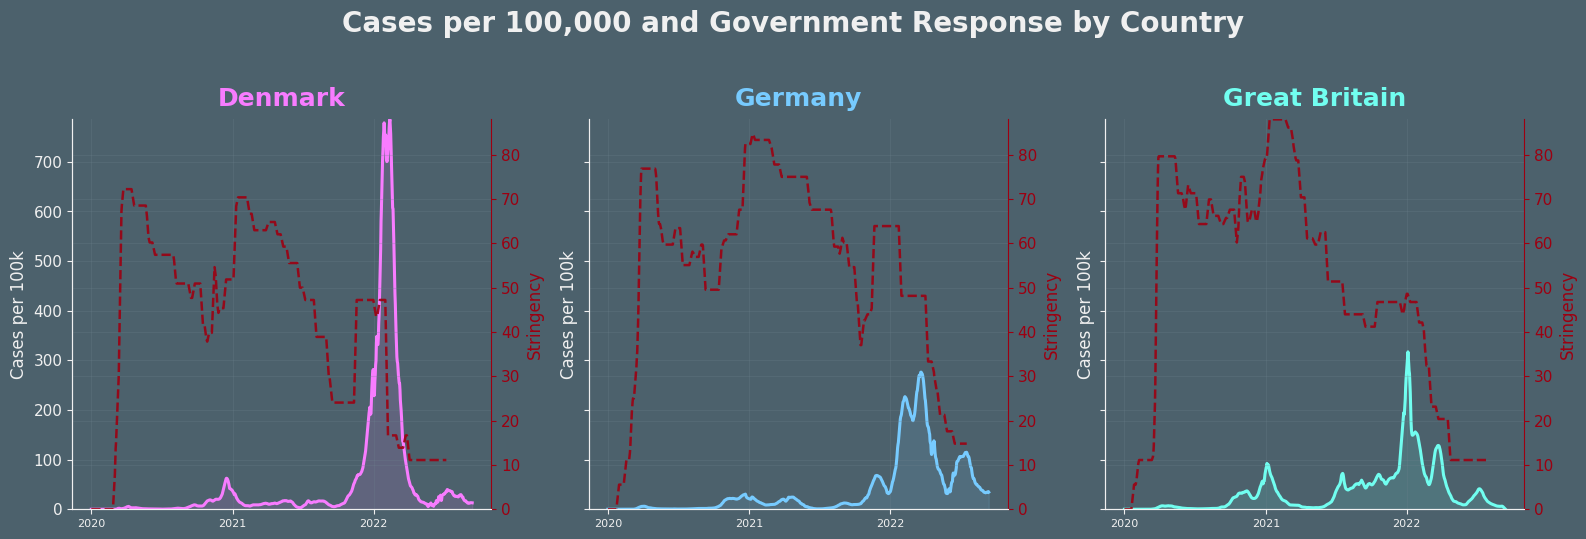

In [152]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --------------------------------------------------
# Population values
# Replace these with the exact source/year you want to use
# --------------------------------------------------
population_map = {
    "DK": 5900000,    # Denmark
    "DE": 84400000,   # Germany
    "GB": 67700000,   # Great Britain / United Kingdom
}

# --------------------------------------------------
# Build a population-adjusted epidemiology table
# --------------------------------------------------
epi_compare_pop = epi_compare.copy()
epi_compare_pop["population"] = epi_compare_pop["location_key"].map(population_map)

# Cases per 100,000 people
epi_compare_pop["cases_per_100k_7d"] = (
    epi_compare_pop["new_confirmed_7d"] / epi_compare_pop["population"] * 100000
)

# Optional: deaths per 100,000 too, if you want later
epi_compare_pop["deaths_per_100k_7d"] = (
    epi_compare_pop["new_deceased_7d"] / epi_compare_pop["population"] * 100000
)

# --------------------------------------------------
# Shared axis limits for fair comparison
# --------------------------------------------------
cases_per_100k_ymax = epi_compare_pop["cases_per_100k_7d"].max()
stringency_ymax = gov_compare["stringency_7d"].max()

# --------------------------------------------------
# Plot: cases per 100k + stringency
# --------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 5.2), sharex=True, sharey=True)

for ax, code in zip(axes, selected_countries):
    epi_plot = (
        epi_compare_pop[epi_compare_pop["location_key"] == code]
        .sort_values("date")
        .copy()
    )
    gov_plot = (
        gov_compare[gov_compare["location_key"] == code]
        .sort_values("date")
        .copy()
    )

    c = COUNTRY_COLORS[code]

    # Left axis: cases per 100k
    ax.plot(
        epi_plot["date"],
        epi_plot["cases_per_100k_7d"],
        color=c,
        linewidth=2.2
    )
    ax.fill_between(
        epi_plot["date"],
        epi_plot["cases_per_100k_7d"],
        color=c,
        alpha=0.12
    )

    ax.set_title(country_names[code], color=c, pad=10)
    ax.set_ylabel("Cases per 100k")
    ax.set_ylim(0, cases_per_100k_ymax)

    # Cleaner axis styling
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Use year ticks only and smaller font
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.tick_params(axis="x", labelsize=8)

    # Right axis: stringency
    ax2 = ax.twinx()
    ax2.plot(
        gov_plot["date"],
        gov_plot["stringency_7d"],
        color=RED,
        linestyle="--",
        linewidth=1.8,
        alpha=0.9
    )
    ax2.set_ylim(0, stringency_ymax)
    ax2.set_ylabel("Stringency", color=RED)
    ax2.tick_params(axis="y", colors=RED)
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_color(RED)

fig.suptitle(
    "Cases per 100,000 and Government Response by Country",
    fontsize=20,
    fontweight="bold",
    y=1.03,
    color=TEXT
)

plt.tight_layout()
plt.show()

## Population-adjusted comparison: deaths and government response

To compare Denmark, Germany, and Great Britain fairly, we normalize death counts by population size.

Instead of plotting raw COVID-19 deaths, we plot:

- **new deaths per 100,000 people**
- **government stringency index**

This makes the death curves comparable across countries with different population sizes.

In this figure:
- the **left axis** shows 7-day average new deaths per 100,000 people,
- the **right axis** shows the Oxford government stringency index,
- and all country panels use the **same x-axis and y-axis scales** to ensure fair visual comparison.

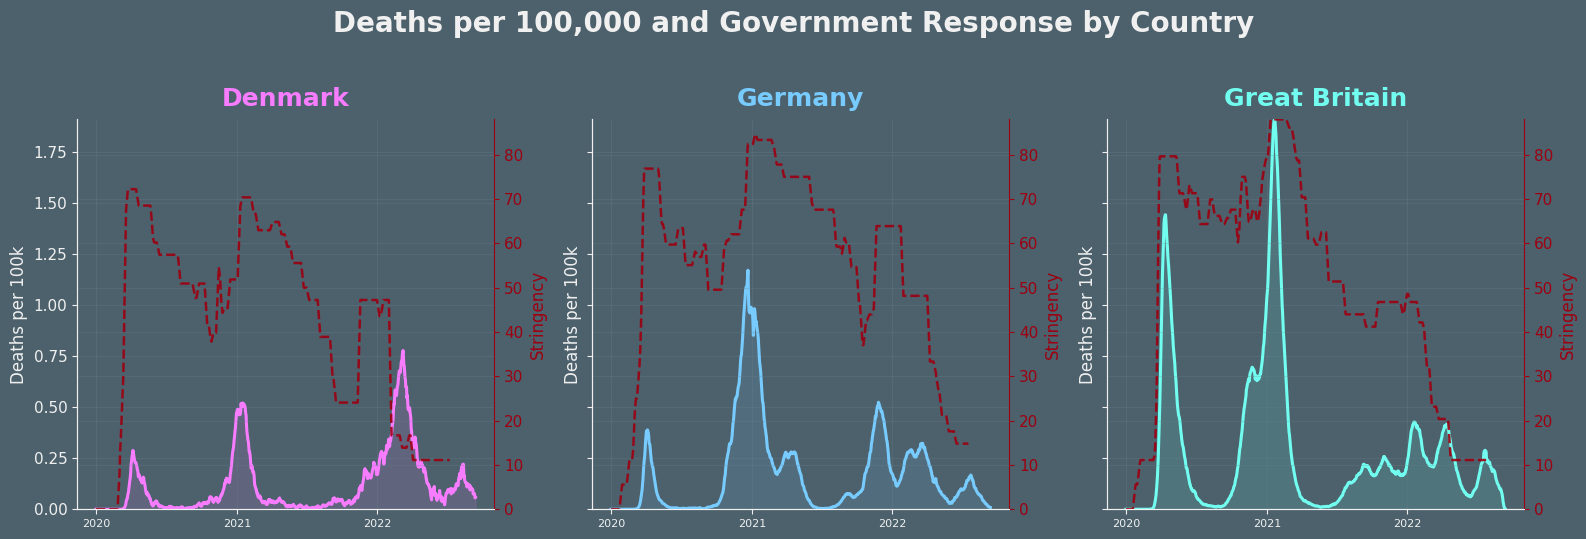

In [153]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --------------------------------------------------
# Population values
# Replace these with the exact source/year you want to use
# --------------------------------------------------
population_map = {
    "DK": 5900000,    # Denmark
    "DE": 84400000,   # Germany
    "GB": 67700000,   # Great Britain / United Kingdom
}

# --------------------------------------------------
# Build a population-adjusted epidemiology table
# --------------------------------------------------
epi_compare_pop = epi_compare.copy()
epi_compare_pop["population"] = epi_compare_pop["location_key"].map(population_map)

# Deaths per 100,000 people
epi_compare_pop["deaths_per_100k_7d"] = (
    epi_compare_pop["new_deceased_7d"] / epi_compare_pop["population"] * 100000
)

# --------------------------------------------------
# Shared axis limits for fair comparison
# --------------------------------------------------
deaths_per_100k_ymax = epi_compare_pop["deaths_per_100k_7d"].max()
stringency_ymax = gov_compare["stringency_7d"].max()

# --------------------------------------------------
# Plot: deaths per 100k + stringency
# --------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 5.2), sharex=True, sharey=True)

for ax, code in zip(axes, selected_countries):
    epi_plot = (
        epi_compare_pop[epi_compare_pop["location_key"] == code]
        .sort_values("date")
        .copy()
    )
    gov_plot = (
        gov_compare[gov_compare["location_key"] == code]
        .sort_values("date")
        .copy()
    )

    c = COUNTRY_COLORS[code]

    # Left axis: deaths per 100k
    ax.plot(
        epi_plot["date"],
        epi_plot["deaths_per_100k_7d"],
        color=c,
        linewidth=2.2
    )
    ax.fill_between(
        epi_plot["date"],
        epi_plot["deaths_per_100k_7d"],
        color=c,
        alpha=0.12
    )

    ax.set_title(country_names[code], color=c, pad=10)
    ax.set_ylabel("Deaths per 100k")
    ax.set_ylim(0, deaths_per_100k_ymax)

    # Cleaner axis styling
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Use year ticks only and smaller font
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.tick_params(axis="x", labelsize=8)

    # Right axis: stringency
    ax2 = ax.twinx()
    ax2.plot(
        gov_plot["date"],
        gov_plot["stringency_7d"],
        color=RED,
        linestyle="--",
        linewidth=1.8,
        alpha=0.9
    )
    ax2.set_ylim(0, stringency_ymax)
    ax2.set_ylabel("Stringency", color=RED)
    ax2.tick_params(axis="y", colors=RED)
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_color(RED)

fig.suptitle(
    "Deaths per 100,000 and Government Response by Country",
    fontsize=20,
    fontweight="bold",
    y=1.03,
    color=TEXT
)

plt.tight_layout()
plt.show()

## Bar chart comparison: cases and deaths per 100,000 inhabitants

Absolute totals are useful for showing global burden, but they are not ideal for comparing countries of different population sizes.

To make Denmark, Germany, and Great Britain comparable, we calculate:

- **confirmed cases per 100,000 inhabitants**
- **deaths per 100,000 inhabitants**

This gives a fairer comparison of the relative COVID-19 burden across the three countries.

In [154]:
# Selected countries
selected_countries = ["DK", "DE", "GB"]

country_names = {
    "DK": "Denmark",
    "DE": "Germany",
    "GB": "Great Britain"
}

# Population values used for normalization
# Replace these if you want to use another specific reference year/source
population = {
    "DK": 5831404,
    "DE": 83166711,
    "GB": 67026292
}

## Compute per-capita values

We use the latest cumulative country-level totals from the epidemiology dataset and convert them to:

- cases per 100,000
- deaths per 100,000

In [155]:
latest_compare = (
    epi_country[epi_country["location_key"].isin(selected_countries)]
    .sort_values(["location_key", "date"])
    .groupby("location_key", as_index=False)[["cumulative_confirmed", "cumulative_deceased"]]
    .last()
    .copy()
)

latest_compare["country"] = latest_compare["location_key"].map(country_names)
latest_compare["population"] = latest_compare["location_key"].map(population)

latest_compare["cases_per_100k"] = (
    latest_compare["cumulative_confirmed"] / latest_compare["population"] * 100000
)

latest_compare["deaths_per_100k"] = (
    latest_compare["cumulative_deceased"] / latest_compare["population"] * 100000
)

latest_compare

,location_key,cumulative_confirmed,cumulative_deceased,country,population,cases_per_100k,deaths_per_100k
0,DE,32604993.0,148728.0,Germany,83166711,39204.379502,178.831167
1,DK,3283706.0,6987.0,Denmark,5831404,56310.727228,119.816771
2,GB,23554971.0,189026.0,Great Britain,67026292,35142.882438,282.017689


## Updated project color palette

From this point onward, we use the updated project palette:

- background: `#4C4153`
- light text: `#F0F0F0`
- soft borders: `#D9E0E4`

Additional accent colors:
- `#3A3A5C`
- `#1A1A2E`
- `#EFDEF0`
- `#DEDAF2`
- `#CDE1ED`
- `#E1ECF3`
- `#D8ECEA`

These colors will be used consistently in the country comparison figures.

In [162]:
BG_DARK = "#4C4153"
LAND_LIGHT = "#F0F0F0"
TEXT_LIGHT = "#F0F0F0"
BORDER_SOFT = "#D9E0E4"

ACCENT_1 = "#3A3A5C"
ACCENT_2 = "#1A1A2E"
ACCENT_3 = "#EFDEF0"
ACCENT_4 = "#DEDAF2"
ACCENT_5 = "#CDE1ED"
ACCENT_6 = "#E1ECF3"
ACCENT_7 = "#D8ECEA"

## Country totals and population normalization

To compare countries fairly, we normalize total confirmed cases and total deaths by population.

We first take the latest cumulative country-level totals from the epidemiology dataset, then divide by population and scale to **per 100,000 inhabitants**.

Note: the epidemiology dataset does not include population, so we add it manually here.

In [163]:
import pandas as pd
import numpy as np

selected_countries = ["DK", "DE", "GB"]

country_names = {
    "DK": "Denmark",
    "DE": "Germany",
    "GB": "Great Britain"
}

country_colors = {
    "DK": "#CDE1ED",
    "DE": "#DEDAF2",
    "GB": "#EFDEF0",
}

# Replace these with the population values from the source you choose to cite
population_lookup = {
    "DK": 5_900_000,
    "DE": 84_000_000,
    "GB": 67_000_000,
}

latest_country_totals = (
    epi_country[epi_country["location_key"].isin(selected_countries)]
    .sort_values(["location_key", "date"])
    .groupby("location_key", as_index=False)[
        ["cumulative_confirmed", "cumulative_deceased"]
    ]
    .last()
    .copy()
)

latest_country_totals["country"] = latest_country_totals["location_key"].map(country_names)
latest_country_totals["population"] = latest_country_totals["location_key"].map(population_lookup)

latest_country_totals["cases_per_100k"] = (
    latest_country_totals["cumulative_confirmed"] / latest_country_totals["population"] * 100000
)

latest_country_totals["deaths_per_100k"] = (
    latest_country_totals["cumulative_deceased"] / latest_country_totals["population"] * 100000
)

latest_country_totals

,location_key,cumulative_confirmed,cumulative_deceased,country,population,cases_per_100k,deaths_per_100k
0,DE,32604993.0,148728.0,Germany,84000000,38815.467857,177.057143
1,DK,3283706.0,6987.0,Denmark,5900000,55656.033898,118.423729
2,GB,23554971.0,189026.0,Great Britain,67000000,35156.673134,282.128358


## Static bar chart: cases and deaths per 100,000

This figure compares Denmark, Germany, and Great Britain using population-normalized values.

Normalization is important because raw totals are strongly influenced by country size.  
By using values per 100,000 inhabitants, the comparison becomes more meaningful.

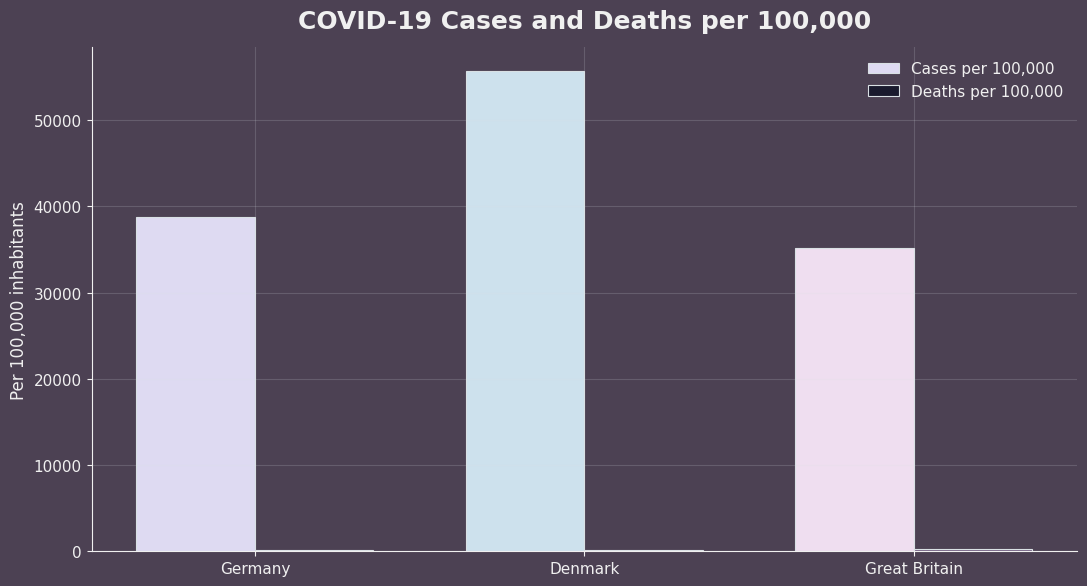

In [164]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

mpl.rcParams["figure.facecolor"] = BG_DARK
mpl.rcParams["axes.facecolor"] = BG_DARK
mpl.rcParams["savefig.facecolor"] = BG_DARK
mpl.rcParams["axes.edgecolor"] = TEXT_LIGHT
mpl.rcParams["axes.labelcolor"] = TEXT_LIGHT
mpl.rcParams["xtick.color"] = TEXT_LIGHT
mpl.rcParams["ytick.color"] = TEXT_LIGHT
mpl.rcParams["text.color"] = TEXT_LIGHT
mpl.rcParams["axes.titleweight"] = "bold"
mpl.rcParams["axes.titlesize"] = 18
mpl.rcParams["axes.labelsize"] = 12
mpl.rcParams["font.size"] = 11
mpl.rcParams["grid.color"] = BORDER_SOFT
mpl.rcParams["grid.alpha"] = 0.18
mpl.rcParams["axes.grid"] = True

plot_df = latest_country_totals.copy()

x = np.arange(len(plot_df))
width = 0.36

fig, ax = plt.subplots(figsize=(11, 6))

case_colors = [country_colors[c] for c in plot_df["location_key"]]
death_colors = [ACCENT_2, ACCENT_1, "#6E5A7E"]

bars1 = ax.bar(
    x - width/2,
    plot_df["cases_per_100k"],
    width,
    label="Cases per 100,000",
    color=case_colors,
    edgecolor=BORDER_SOFT,
    linewidth=0.8
)

bars2 = ax.bar(
    x + width/2,
    plot_df["deaths_per_100k"],
    width,
    label="Deaths per 100,000",
    color=death_colors,
    edgecolor=BORDER_SOFT,
    linewidth=0.8
)

ax.set_title("COVID-19 Cases and Deaths per 100,000", pad=14)
ax.set_ylabel("Per 100,000 inhabitants")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["country"])
ax.legend(frameon=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Interactive bar chart: cases and deaths per 100,000

This Plotly version supports:
- hover details,
- cleaner visual presentation,
- and easier later integration into a website.

It compares the same two normalized metrics:
- cases per 100,000
- deaths per 100,000

In [165]:
import plotly.graph_objects as go

plot_df = latest_country_totals.copy()

fig = go.Figure()

fig.add_trace(go.Bar(
    x=plot_df["country"],
    y=plot_df["cases_per_100k"],
    name="Cases per 100,000",
    marker=dict(
        color=[country_colors[c] for c in plot_df["location_key"]],
        line=dict(color=BORDER_SOFT, width=1)
    ),
    hovertemplate="<b>%{x}</b><br>Cases per 100k: %{y:,.1f}<extra></extra>"
))

fig.add_trace(go.Bar(
    x=plot_df["country"],
    y=plot_df["deaths_per_100k"],
    name="Deaths per 100,000",
    marker=dict(
        color=[ACCENT_2, ACCENT_1, "#6E5A7E"],
        line=dict(color=BORDER_SOFT, width=1)
    ),
    hovertemplate="<b>%{x}</b><br>Deaths per 100k: %{y:,.1f}<extra></extra>"
))

fig.update_layout(
    barmode="group",
    paper_bgcolor=BG_DARK,
    plot_bgcolor=BG_DARK,
    font=dict(color=TEXT_LIGHT, size=13),
    title=dict(
        text="COVID-19 Cases and Deaths per 100,000",
        x=0.03,
        xanchor="left",
        font=dict(size=24, color=TEXT_LIGHT)
    ),
    xaxis_title="",
    yaxis_title="Per 100,000 inhabitants",
    legend_title="Metric"
)

fig.update_xaxes(showgrid=False, linecolor=BORDER_SOFT)
fig.update_yaxes(showgrid=True, gridcolor=BORDER_SOFT, linecolor=BORDER_SOFT)

fig.show()

## Optional split view: separate bar charts

If the grouped bars feel visually crowded, it can also be useful to separate the two metrics into different charts.

This often improves readability and helps avoid scale confusion.

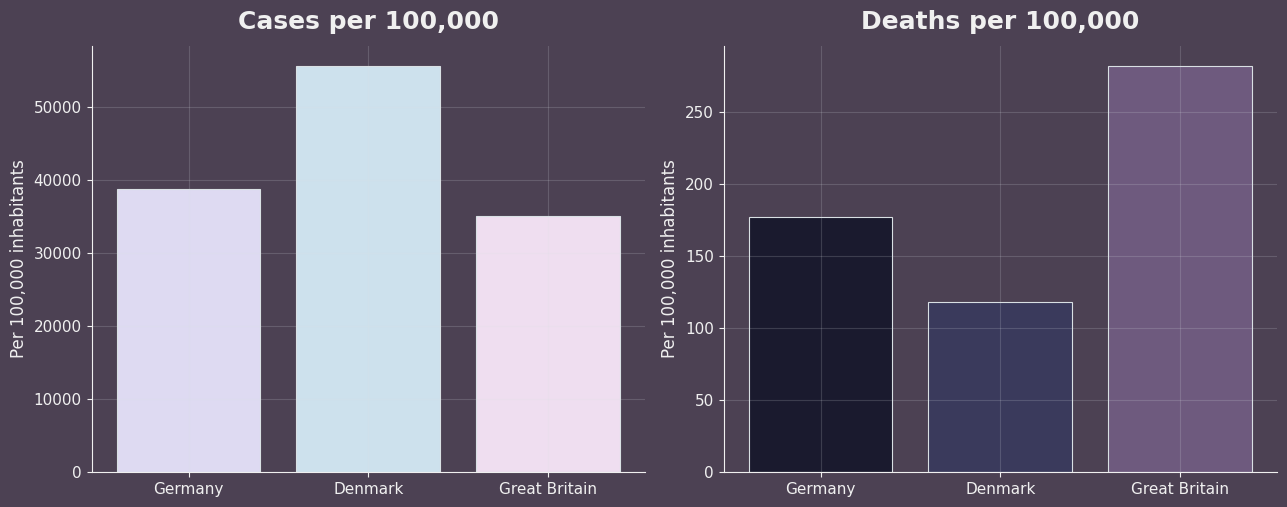

In [166]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2), sharey=False)

# Cases
axes[0].bar(
    latest_country_totals["country"],
    latest_country_totals["cases_per_100k"],
    color=[country_colors[c] for c in latest_country_totals["location_key"]],
    edgecolor=BORDER_SOFT,
    linewidth=0.8
)
axes[0].set_title("Cases per 100,000", pad=12)
axes[0].set_ylabel("Per 100,000 inhabitants")
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# Deaths
axes[1].bar(
    latest_country_totals["country"],
    latest_country_totals["deaths_per_100k"],
    color=[ACCENT_2, ACCENT_1, "#6E5A7E"],
    edgecolor=BORDER_SOFT,
    linewidth=0.8
)
axes[1].set_title("Deaths per 100,000", pad=12)
axes[1].set_ylabel("Per 100,000 inhabitants")
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

fig.patch.set_facecolor(BG_DARK)
plt.tight_layout()
plt.show()

**Interpretation note:**  
These values are normalized per 100,000 inhabitants in order to make the country comparison fairer. Raw cumulative totals would otherwise be dominated by country size.

# Telling the story: COVID-19 waves and government response in Denmark, Germany, and Great Britain

In this section, we shift from a global overview to a focused comparison of three European countries:

- Denmark
- Germany
- Great Britain

These countries are geographically close, but their pandemic trajectories and policy responses were not identical.  
Our goal is to explore three linked questions:

1. **When did the major waves happen?**
2. **How did government stringency change over time?**
3. **Do the timelines of infections, deaths, and response suggest different national strategies or outcomes?**

To answer these questions, we combine:
- static visualizations for clear comparison,
- interactive line charts for exploration,
- and heatmaps for month-by-month pattern detection.

## Setup for country comparison

We define the three countries, their display names, and a consistent visual style for the story section.

In [167]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import plotly.express as px
import plotly.graph_objects as go

BG_DARK = "#4C4153"
LAND_LIGHT = "#F0F0F0"
TEXT_LIGHT = "#F0F0F0"
BORDER_SOFT = "#D9E0E4"

ACCENT_1 = "#3A3A5C"
ACCENT_2 = "#1A1A2E"
ACCENT_3 = "#EFDEF0"
ACCENT_4 = "#DEDAF2"
ACCENT_5 = "#CDE1ED"
ACCENT_6 = "#E1ECF3"
ACCENT_7 = "#D8ECEA"

selected_countries = ["DK", "DE", "GB"]

country_names = {
    "DK": "Denmark",
    "DE": "Germany",
    "GB": "Great Britain"
}

country_colors = {
    "DK": ACCENT_5,
    "DE": ACCENT_1,
    "GB": ACCENT_3,
}

mpl.rcParams["figure.facecolor"] = BG_DARK
mpl.rcParams["axes.facecolor"] = BG_DARK
mpl.rcParams["savefig.facecolor"] = BG_DARK
mpl.rcParams["axes.edgecolor"] = TEXT_LIGHT
mpl.rcParams["axes.labelcolor"] = TEXT_LIGHT
mpl.rcParams["xtick.color"] = TEXT_LIGHT
mpl.rcParams["ytick.color"] = TEXT_LIGHT
mpl.rcParams["text.color"] = TEXT_LIGHT
mpl.rcParams["axes.titleweight"] = "bold"
mpl.rcParams["axes.titlesize"] = 18
mpl.rcParams["axes.labelsize"] = 12
mpl.rcParams["font.size"] = 11
mpl.rcParams["grid.color"] = BORDER_SOFT
mpl.rcParams["grid.alpha"] = 0.18
mpl.rcParams["axes.grid"] = True

## Prepare smoothed time series

We prepare country-level time series for:

- new confirmed cases,
- new deaths,
- and government stringency.

To reduce reporting noise, we use **7-day rolling averages**.

In [168]:
epi_compare = (
    epi_country[epi_country["location_key"].isin(selected_countries)]
    .copy()
    .sort_values(["location_key", "date"])
)

gov_compare = (
    gov_country[gov_country["location_key"].isin(selected_countries)]
    .copy()
    .sort_values(["location_key", "date"])
)

epi_compare["new_confirmed_7d"] = (
    epi_compare.groupby("location_key")["new_confirmed"]
    .transform(lambda s: s.rolling(7, min_periods=1).mean())
)

epi_compare["new_deceased_7d"] = (
    epi_compare.groupby("location_key")["new_deceased"]
    .transform(lambda s: s.rolling(7, min_periods=1).mean())
)

gov_compare["stringency_7d"] = (
    gov_compare.groupby("location_key")["stringency_index"]
    .transform(lambda s: s.rolling(7, min_periods=1).mean())
)

epi_compare["country"] = epi_compare["location_key"].map(country_names)
gov_compare["country"] = gov_compare["location_key"].map(country_names)

## Story beat 1: The timing of the waves

Our first question is simple: **when did the major waves happen in each country?**

A shared-axis small-multiple chart is useful here because it preserves fair comparison:
- the **same x-axis**
- the **same y-axis**
- one panel per country

This avoids misleading scale differences between panels.

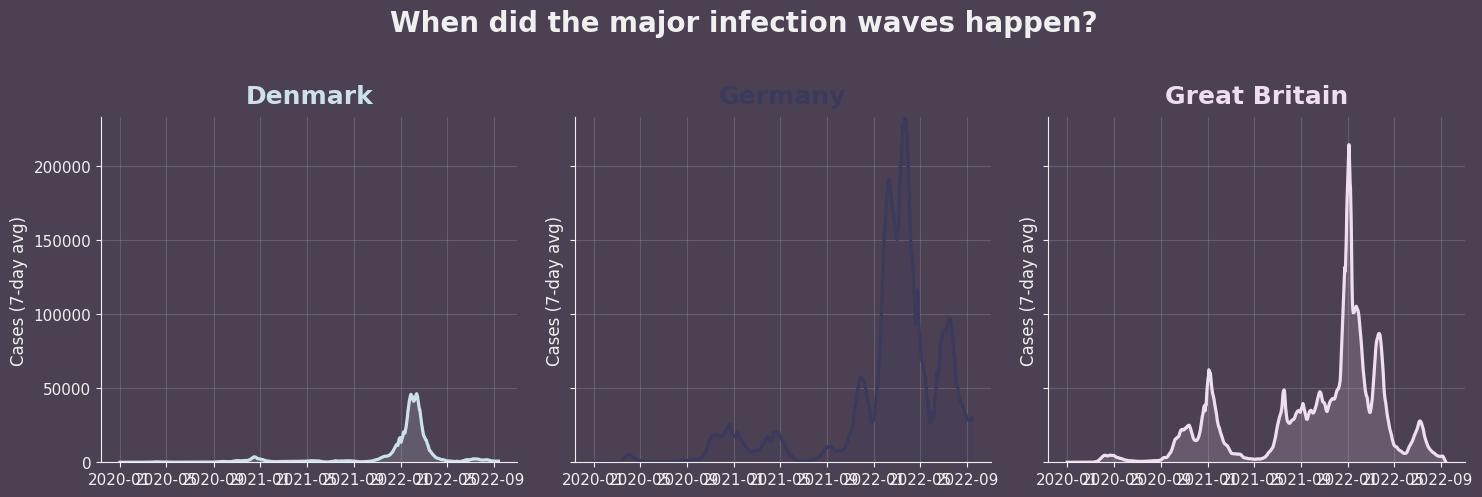

In [169]:
cases_ymax = epi_compare["new_confirmed_7d"].max()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharex=True, sharey=True)

for ax, code in zip(axes, selected_countries):
    df_plot = epi_compare[epi_compare["location_key"] == code]
    c = country_colors[code]

    ax.plot(df_plot["date"], df_plot["new_confirmed_7d"], color=c, linewidth=2.3)
    ax.fill_between(df_plot["date"], df_plot["new_confirmed_7d"], color=c, alpha=0.16)

    ax.set_title(country_names[code], color=c, pad=10)
    ax.set_ylim(0, cases_ymax)
    ax.set_ylabel("Cases (7-day avg)")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle("When did the major infection waves happen?", fontsize=20, fontweight="bold", y=1.03, color=TEXT_LIGHT)
plt.tight_layout()
plt.show()

## Interactive exploration: zoom into different phases

The next figure allows us to zoom into specific phases of the pandemic.

This is useful because:
- the first wave looks very different from later waves,
- later periods often have much larger case counts,
- and interactive zoom makes it easier to compare timing across countries.

In [170]:
fig = go.Figure()

for code in selected_countries:
    df_country = epi_compare[epi_compare["location_key"] == code]
    fig.add_trace(
        go.Scatter(
            x=df_country["date"],
            y=df_country["new_confirmed_7d"],
            mode="lines",
            name=country_names[code],
            line=dict(color=country_colors[code], width=2.6),
            hovertemplate="<b>%{fullData.name}</b><br>Date: %{x|%Y-%m-%d}<br>Cases: %{y:,.0f}<extra></extra>"
        )
    )

fig.update_layout(
    paper_bgcolor=BG_DARK,
    plot_bgcolor=BG_DARK,
    font=dict(color=TEXT_LIGHT),
    title="Interactive exploration of infection waves",
    title_font=dict(size=24, color=TEXT_LIGHT),
    xaxis_title="",
    yaxis_title="Cases (7-day avg)",
    hovermode="x unified",
    legend_title="Country"
)

fig.update_xaxes(
    showgrid=True,
    gridcolor=BORDER_SOFT,
    rangeslider_visible=True,
    rangeselector=dict(
        bgcolor=LAND_LIGHT,
        activecolor=ACCENT_1,
        buttons=list([
            dict(count=6, label="6m", step="month", stepmode="backward"),
            dict(count=1, label="1y", step="year", stepmode="backward"),
            dict(count=2, label="2y", step="year", stepmode="backward"),
            dict(step="all", label="All")
        ])
    )
)

fig.update_yaxes(showgrid=True, gridcolor=BORDER_SOFT)
fig.show()

## Story beat 2: Did death waves follow the same pattern?

Cases alone do not tell the full story.  
A second key question is whether **death waves followed the same pattern** as infection waves.

Comparing cases and deaths can reveal:
- whether later waves were as severe as earlier ones,
- whether peaks in infections translated into peaks in mortality,
- and whether the relationship changed over time.

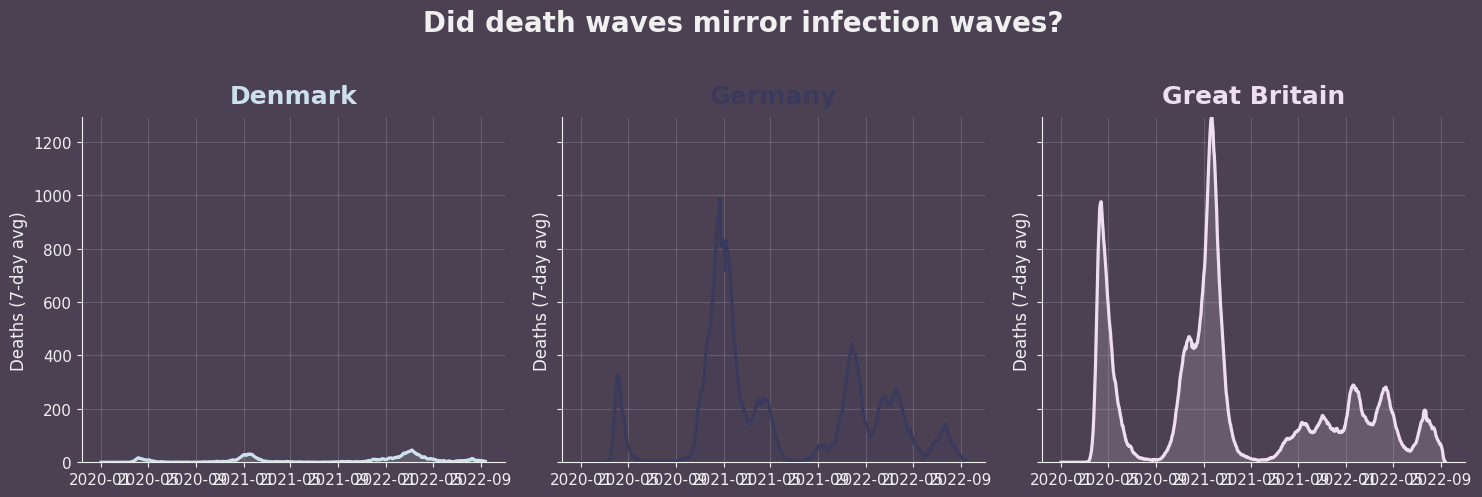

In [171]:
deaths_ymax = epi_compare["new_deceased_7d"].max()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharex=True, sharey=True)

for ax, code in zip(axes, selected_countries):
    df_plot = epi_compare[epi_compare["location_key"] == code]
    c = country_colors[code]

    ax.plot(df_plot["date"], df_plot["new_deceased_7d"], color=c, linewidth=2.3)
    ax.fill_between(df_plot["date"], df_plot["new_deceased_7d"], color=c, alpha=0.16)

    ax.set_title(country_names[code], color=c, pad=10)
    ax.set_ylim(0, deaths_ymax)
    ax.set_ylabel("Deaths (7-day avg)")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle("Did death waves mirror infection waves?", fontsize=20, fontweight="bold", y=1.03, color=TEXT_LIGHT)
plt.tight_layout()
plt.show()

## Population-normalized burden

Raw totals are strongly influenced by country size.  
To compare countries more fairly, we normalize cumulative cases and deaths by population and report them **per 100,000 inhabitants**.

This allows us to compare total burden more meaningfully across Denmark, Germany, and Great Britain.

In [172]:
population_lookup = {
    "DK": 5_900_000,
    "DE": 84_000_000,
    "GB": 67_000_000,
}

latest_country_totals = (
    epi_country[epi_country["location_key"].isin(selected_countries)]
    .sort_values(["location_key", "date"])
    .groupby("location_key", as_index=False)[["cumulative_confirmed", "cumulative_deceased"]]
    .last()
    .copy()
)

latest_country_totals["country"] = latest_country_totals["location_key"].map(country_names)
latest_country_totals["population"] = latest_country_totals["location_key"].map(population_lookup)

latest_country_totals["cases_per_100k"] = (
    latest_country_totals["cumulative_confirmed"] / latest_country_totals["population"] * 100000
)
latest_country_totals["deaths_per_100k"] = (
    latest_country_totals["cumulative_deceased"] / latest_country_totals["population"] * 100000
)

latest_country_totals

,location_key,cumulative_confirmed,cumulative_deceased,country,population,cases_per_100k,deaths_per_100k
0,DE,32604993.0,148728.0,Germany,84000000,38815.467857,177.057143
1,DK,3283706.0,6987.0,Denmark,5900000,55656.033898,118.423729
2,GB,23554971.0,189026.0,Great Britain,67000000,35156.673134,282.128358


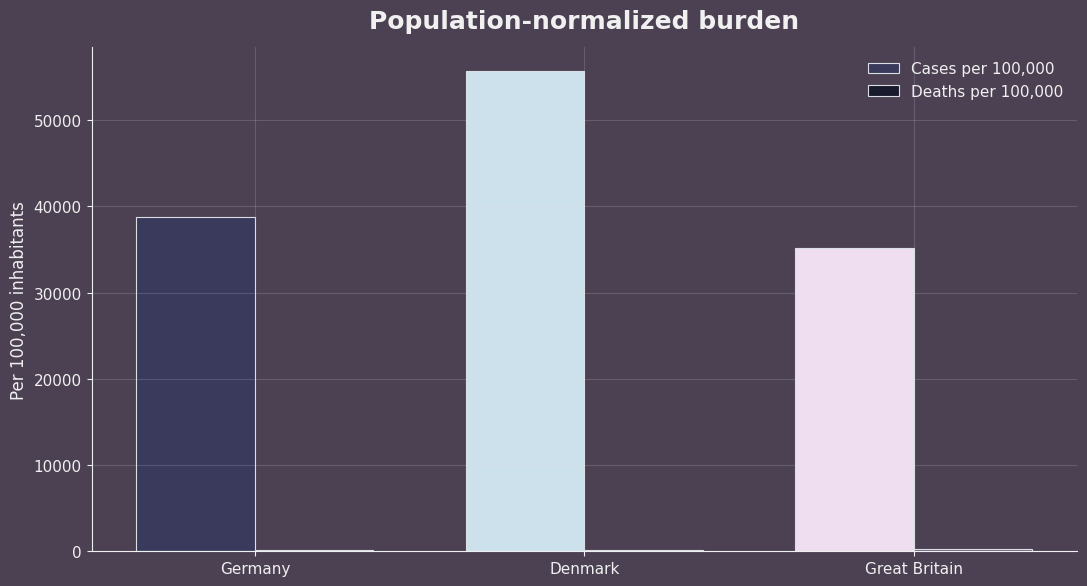

In [173]:
x = np.arange(len(latest_country_totals))
width = 0.36

fig, ax = plt.subplots(figsize=(11, 6))

bars1 = ax.bar(
    x - width/2,
    latest_country_totals["cases_per_100k"],
    width,
    label="Cases per 100,000",
    color=[country_colors[c] for c in latest_country_totals["location_key"]],
    edgecolor=BORDER_SOFT,
    linewidth=0.8
)

bars2 = ax.bar(
    x + width/2,
    latest_country_totals["deaths_per_100k"],
    width,
    label="Deaths per 100,000",
    color=[ACCENT_2, ACCENT_1, "#6E5A7E"],
    edgecolor=BORDER_SOFT,
    linewidth=0.8
)

ax.set_title("Population-normalized burden", pad=14)
ax.set_ylabel("Per 100,000 inhabitants")
ax.set_xticks(x)
ax.set_xticklabels(latest_country_totals["country"])
ax.legend(frameon=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Story beat 3: How strict were government responses?

Next, we compare the Oxford government stringency index.

This helps us examine whether the three countries:
- responded at the same time,
- reached similar levels of strictness,
- or maintained restrictions for different durations.

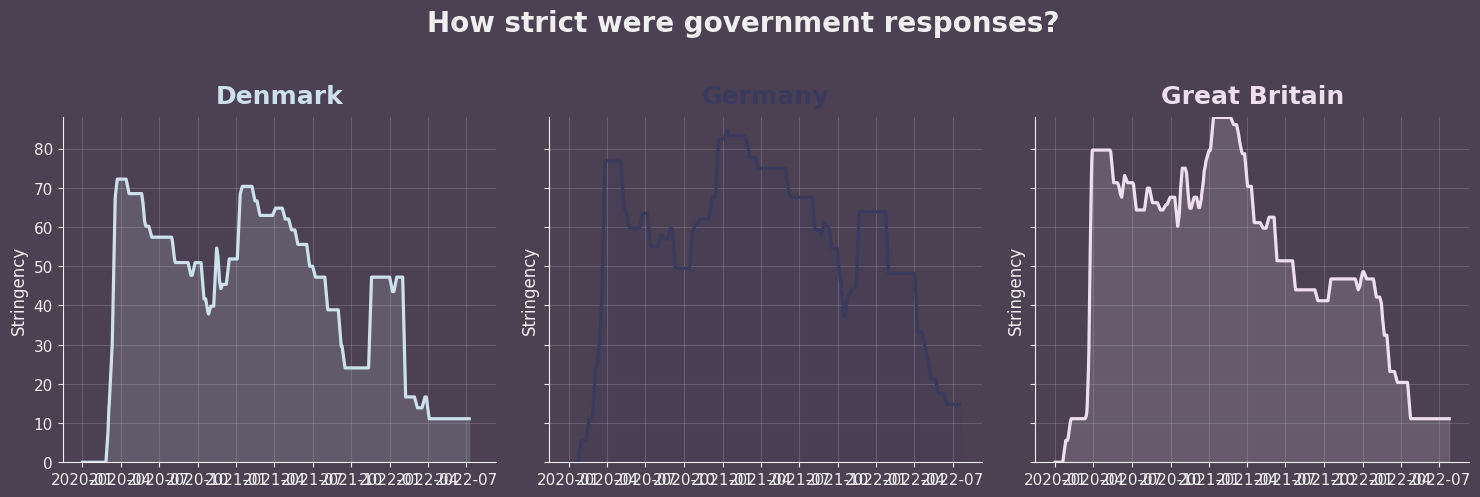

In [174]:
stringency_ymax = gov_compare["stringency_7d"].max()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharex=True, sharey=True)

for ax, code in zip(axes, selected_countries):
    df_plot = gov_compare[gov_compare["location_key"] == code]
    c = country_colors[code]

    ax.plot(df_plot["date"], df_plot["stringency_7d"], color=c, linewidth=2.3)
    ax.fill_between(df_plot["date"], df_plot["stringency_7d"], color=c, alpha=0.16)

    ax.set_title(country_names[code], color=c, pad=10)
    ax.set_ylim(0, stringency_ymax)
    ax.set_ylabel("Stringency")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle("How strict were government responses?", fontsize=20, fontweight="bold", y=1.03, color=TEXT_LIGHT)
plt.tight_layout()
plt.show()

## Interactive exploration: stringency over time

This interactive chart makes it easier to inspect the timing of response changes and compare the duration of stricter periods across the three countries.

In [175]:
fig = px.line(
    gov_compare,
    x="date",
    y="stringency_7d",
    color="country",
    color_discrete_map={
        "Denmark": country_colors["DK"],
        "Germany": country_colors["DE"],
        "Great Britain": country_colors["GB"],
    },
    title="Interactive comparison of government stringency"
)

fig.update_layout(
    paper_bgcolor=BG_DARK,
    plot_bgcolor=BG_DARK,
    font=dict(color=TEXT_LIGHT),
    title_font=dict(size=24, color=TEXT_LIGHT),
    xaxis_title="",
    yaxis_title="Stringency (7-day avg)",
    legend_title="Country",
    hovermode="x unified"
)

fig.update_xaxes(showgrid=True, gridcolor=BORDER_SOFT, rangeslider_visible=True)
fig.update_yaxes(showgrid=True, gridcolor=BORDER_SOFT)

fig.show()

## Story beat 4: Did restrictions rise before or after case surges?

To connect response and spread, we overlay:
- cases
- and stringency

for each country.

This does not prove causality, but it helps us visually examine:
- whether restrictions seem to rise ahead of case surges,
- whether they react to rising cases,
- and whether the three countries differ in timing.

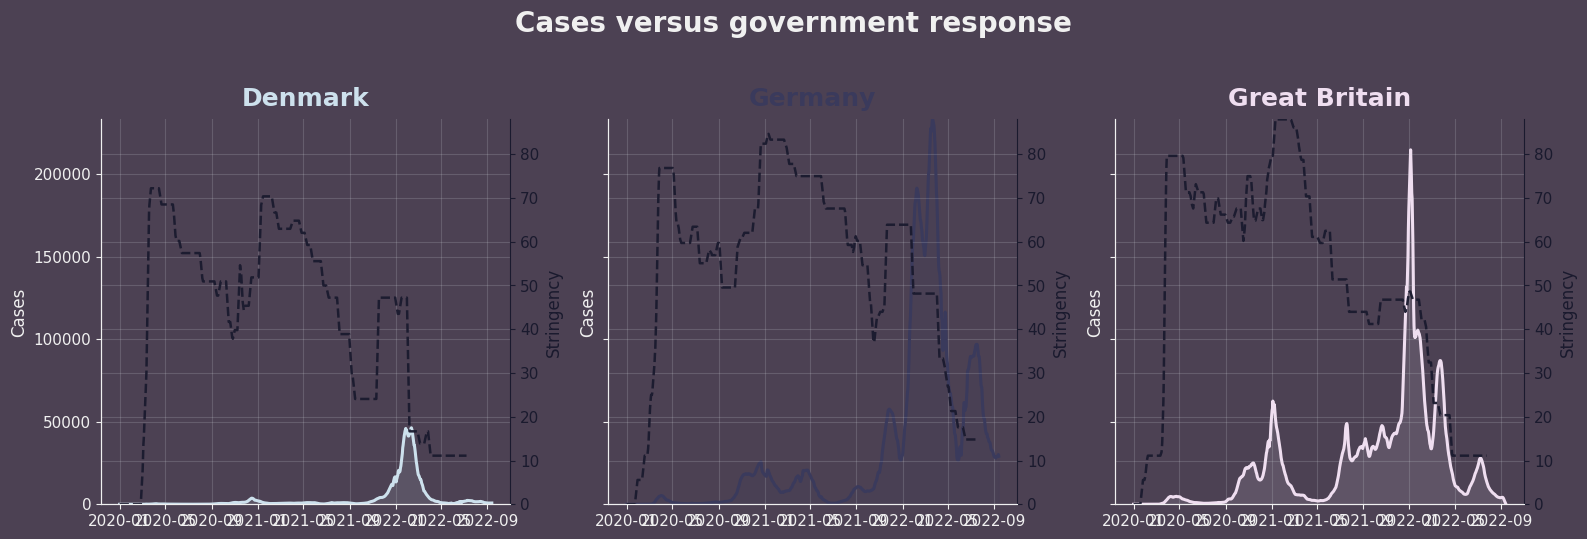

In [176]:
cases_ymax = epi_compare["new_confirmed_7d"].max()
stringency_ymax = gov_compare["stringency_7d"].max()

fig, axes = plt.subplots(1, 3, figsize=(16, 5.2), sharex=True, sharey=True)

for ax, code in zip(axes, selected_countries):
    epi_plot = epi_compare[epi_compare["location_key"] == code].sort_values("date")
    gov_plot = gov_compare[gov_compare["location_key"] == code].sort_values("date")
    c = country_colors[code]

    ax.plot(epi_plot["date"], epi_plot["new_confirmed_7d"], color=c, linewidth=2.2)
    ax.fill_between(epi_plot["date"], epi_plot["new_confirmed_7d"], color=c, alpha=0.12)
    ax.set_title(country_names[code], color=c, pad=10)
    ax.set_ylabel("Cases")
    ax.set_ylim(0, cases_ymax)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax2 = ax.twinx()
    ax2.plot(gov_plot["date"], gov_plot["stringency_7d"], color=ACCENT_2, linestyle="--", linewidth=1.8, alpha=0.95)
    ax2.set_ylim(0, stringency_ymax)
    ax2.set_ylabel("Stringency", color=ACCENT_2)
    ax2.tick_params(axis="y", colors=ACCENT_2)
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_color(ACCENT_2)

fig.suptitle("Cases versus government response", fontsize=20, fontweight="bold", y=1.03, color=TEXT_LIGHT)
plt.tight_layout()
plt.show()

## Story beat 5: Month-by-month comparison

Heatmaps help us compare patterns more compactly than line charts.

By aggregating to the monthly level, we can more easily see:
- when waves intensified,
- when deaths were highest,
- and when stringency was strongest.

In [177]:
epi_monthly = epi_compare.copy()
epi_monthly["year"] = epi_monthly["date"].dt.year
epi_monthly["month"] = epi_monthly["date"].dt.month
epi_monthly["month_name"] = epi_monthly["date"].dt.strftime("%b")

epi_monthly_agg = (
    epi_monthly.groupby(["location_key", "country", "year", "month", "month_name"], as_index=False)
    .agg(
        avg_cases=("new_confirmed_7d", "mean"),
        avg_deaths=("new_deceased_7d", "mean")
    )
)

gov_monthly = gov_compare.copy()
gov_monthly["year"] = gov_monthly["date"].dt.year
gov_monthly["month"] = gov_monthly["date"].dt.month
gov_monthly["month_name"] = gov_monthly["date"].dt.strftime("%b")

gov_monthly_agg = (
    gov_monthly.groupby(["location_key", "country", "year", "month", "month_name"], as_index=False)
    .agg(
        avg_stringency=("stringency_7d", "mean")
    )
)

month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

## Heatmap: monthly cases by country

This heatmap shows average monthly cases for one year at a time.

A year-by-year view makes it easier to compare the changing shape of the pandemic across the three countries.

In [178]:
year_to_plot = 2021

heat_cases = epi_monthly_agg[epi_monthly_agg["year"] == year_to_plot].copy()
heat_cases["month_name"] = pd.Categorical(heat_cases["month_name"], categories=month_order, ordered=True)
heat_cases = heat_cases.sort_values(["country", "month"])

fig = px.density_heatmap(
    heat_cases,
    x="month_name",
    y="country",
    z="avg_cases",
    histfunc="avg",
    color_continuous_scale=[
        [0.0, ACCENT_3],
        [0.20, "#D9B8E1"],
        [0.40, "#B78AC5"],
        [0.60, "#8E5A9E"],
        [0.80, "#5F3D73"],
        [1.00, ACCENT_2],
    ],
    title=f"Monthly cases by country — {year_to_plot}"
)

fig.update_layout(
    paper_bgcolor=BG_DARK,
    plot_bgcolor=BG_DARK,
    font=dict(color=TEXT_LIGHT),
    title_font=dict(size=24, color=TEXT_LIGHT),
    xaxis_title="Month",
    yaxis_title="Country",
    coloraxis_colorbar=dict(
        title=dict(text="Average cases", font=dict(color=TEXT_LIGHT)),
        tickfont=dict(color=TEXT_LIGHT)
    )
)

fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=False)
fig.show()

## Heatmap: monthly deaths by country

This heatmap shows average monthly deaths for the selected year.

In [179]:
year_to_plot = 2021

heat_deaths = epi_monthly_agg[epi_monthly_agg["year"] == year_to_plot].copy()
heat_deaths["month_name"] = pd.Categorical(heat_deaths["month_name"], categories=month_order, ordered=True)
heat_deaths = heat_deaths.sort_values(["country", "month"])

fig = px.density_heatmap(
    heat_deaths,
    x="month_name",
    y="country",
    z="avg_deaths",
    histfunc="avg",
    color_continuous_scale=[
        [0.0, ACCENT_3],
        [0.20, "#D9B8E1"],
        [0.40, "#B78AC5"],
        [0.60, "#8E5A9E"],
        [0.80, "#5F3D73"],
        [1.00, ACCENT_2],
    ],
    title=f"Monthly deaths by country — {year_to_plot}"
)

fig.update_layout(
    paper_bgcolor=BG_DARK,
    plot_bgcolor=BG_DARK,
    font=dict(color=TEXT_LIGHT),
    title_font=dict(size=24, color=TEXT_LIGHT),
    xaxis_title="Month",
    yaxis_title="Country",
    coloraxis_colorbar=dict(
        title=dict(text="Average deaths", font=dict(color=TEXT_LIGHT)),
        tickfont=dict(color=TEXT_LIGHT)
    )
)

fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=False)
fig.show()

## Heatmap: monthly government stringency by country

This heatmap shows average monthly government stringency for the selected year.

In [180]:
year_to_plot = 2021

heat_stringency = gov_monthly_agg[gov_monthly_agg["year"] == year_to_plot].copy()
heat_stringency["month_name"] = pd.Categorical(heat_stringency["month_name"], categories=month_order, ordered=True)
heat_stringency = heat_stringency.sort_values(["country", "month"])

fig = px.density_heatmap(
    heat_stringency,
    x="month_name",
    y="country",
    z="avg_stringency",
    histfunc="avg",
    color_continuous_scale=[
        [0.0, ACCENT_7],
        [0.25, ACCENT_6],
        [0.50, ACCENT_5],
        [0.75, ACCENT_4],
        [1.00, ACCENT_1],
    ],
    title=f"Monthly government stringency by country — {year_to_plot}"
)

fig.update_layout(
    paper_bgcolor=BG_DARK,
    plot_bgcolor=BG_DARK,
    font=dict(color=TEXT_LIGHT),
    title_font=dict(size=24, color=TEXT_LIGHT),
    xaxis_title="Month",
    yaxis_title="Country",
    coloraxis_colorbar=dict(
        title=dict(text="Average stringency", font=dict(color=TEXT_LIGHT)),
        tickfont=dict(color=TEXT_LIGHT)
    )
)

fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=False)
fig.show()

## Interactive heatmap with year dropdown

This final figure allows the user to switch between years and compare monthly case intensity across Denmark, Germany, and Great Britain.

In [181]:
fig = go.Figure()

heat_years = sorted(epi_monthly_agg["year"].dropna().unique())
trace_info = []

for year in heat_years:
    heat_cases = epi_monthly_agg[epi_monthly_agg["year"] == year].copy()
    heat_cases["month_name"] = pd.Categorical(heat_cases["month_name"], categories=month_order, ordered=True)
    heat_cases = heat_cases.sort_values(["country", "month"])

    pivot_df = heat_cases.pivot(index="country", columns="month_name", values="avg_cases").reindex(columns=month_order)

    fig.add_trace(
        go.Heatmap(
            z=pivot_df.values,
            x=pivot_df.columns,
            y=pivot_df.index,
            colorscale=[
                [0.0, ACCENT_3],
                [0.20, "#D9B8E1"],
                [0.40, "#B78AC5"],
                [0.60, "#8E5A9E"],
                [0.80, "#5F3D73"],
                [1.00, ACCENT_2],
            ],
            visible=(year == heat_years[0]),
            colorbar=dict(title="Avg cases")
        )
    )
    trace_info.append(year)

buttons = []
for year in heat_years:
    buttons.append(
        dict(
            label=str(year),
            method="update",
            args=[
                {"visible": [y == year for y in trace_info]},
                {"title": f"Monthly cases by country — {year}"}
            ]
        )
    )

fig.update_layout(
    paper_bgcolor=BG_DARK,
    plot_bgcolor=BG_DARK,
    font=dict(color=TEXT_LIGHT),
    title=f"Monthly cases by country — {heat_years[0]}",
    title_font=dict(size=24, color=TEXT_LIGHT),
    xaxis_title="Month",
    yaxis_title="Country",
    updatemenus=[
        dict(
            type="dropdown",
            direction="down",
            x=1.02,
            y=1.0,
            showactive=True,
            buttons=buttons
        )
    ]
)

fig.show()

## How to interpret Oxford policy scales

Several variables in the Oxford Government Response dataset, such as **school closing** and **workplace closing**, are recorded on small numeric scales like **0 to 3**.

These scales are **ordinal policy indicators**. This means they represent **ordered levels of policy strictness**, not continuous measured quantities.

In general, they should be interpreted as:

- a **higher value** means a **stricter policy**
- a **lower value** means a **less strict policy**

For example, a workplace-closing variable may follow this pattern:

- **0** = no measures
- **1** = recommendation
- **2** = partial requirement
- **3** = broad or full requirement

The same general logic applies to school-closing and similar Oxford response variables.

### Important interpretation note
These variables are **not** like cases, deaths, temperature, or income, where the numbers represent continuous measured amounts.  
Instead, they are **coded categories** placed in order from less strict to more strict.

This means:

- **3** is stricter than **2**
- **2** is stricter than **1**
- but the step from **1 to 2** should not automatically be treated as the same quantitative jump as the step from **2 to 3**

### What these scales are useful for
These policy indicators are helpful for showing:

- when governments introduced restrictions,
- when restrictions became stricter or more relaxed,
- and how policy timing relates to changes in cases or deaths.

### What they should not be used for
These scales should **not** be interpreted as exact measurements of how many people, schools, or workplaces were affected.  
They describe the **level of policy response**, not its exact real-world magnitude.

## Cases per 100,000 and school closings by country

This figure compares **Denmark, Germany, and Great Britain** using two aligned views for each country.

### Top row: new confirmed cases
The upper panels show **new confirmed COVID-19 cases per 100,000 people**, smoothed with a **7-day rolling average**.  
Using cases per 100,000 makes the countries more comparable by adjusting for population size.

### Bottom row: school closing policy
The lower panels show the **school closing policy level** from the Oxford Government Response dataset.  
This variable is an **ordinal policy measure**, not a population-normalized quantity, so it is shown on its own scale from **0 to 3**.

The values represent:

- **0** = no measures
- **1** = recommend closing or altered attendance
- **2** = require closing some levels or categories
- **3** = require closing all levels

### Why this layout is fair
We do **not** place cases and school closing on the same axis, because they measure fundamentally different things.  
Instead, we align them vertically and keep the scales consistent across countries:

- the **same case scale** is used for all countries in the top row
- the **same school-closing scale** is used for all countries in the bottom row

This allows us to compare:
- when case waves occurred,
- when school-closing policies became stricter or more relaxed,
- and whether changes in policy happened before, during, or after major waves.

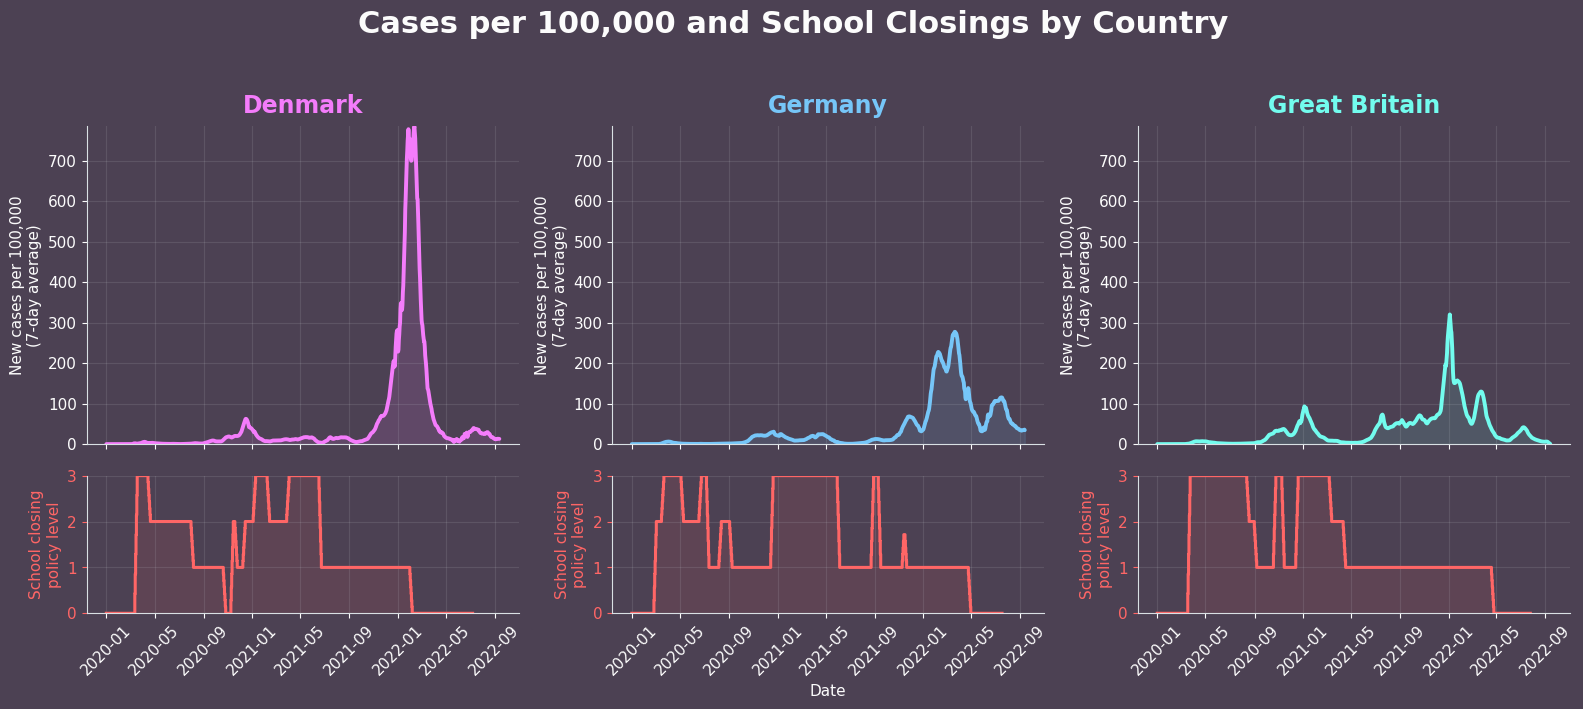

In [193]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# -----------------------------
# Colors
# -----------------------------
BG_DARK = "#4C4153"
TEXT_LIGHT = "#FCFCFC"
BORDER_SOFT = "#D9E0E4"

COUNTRY_COLORS = {
    "DK": "#F47CFB",   # Denmark
    "DE": "#76C6F8",   # Germany
    "GB": "#72FCEE",   # Great Britain
}

SCHOOL_COLOR = "#FF6666"

selected_countries = ["DK", "DE", "GB"]

country_names = {
    "DK": "Denmark",
    "DE": "Germany",
    "GB": "Great Britain"
}

# Replace with your final chosen source if needed
population_lookup = {
    "DK": 5_900_000,
    "DE": 84_000_000,
    "GB": 67_000_000,
}

# -----------------------------
# Build epidemiology table
# -----------------------------
epi_compare = (
    epi_country[epi_country["location_key"].isin(selected_countries)]
    .copy()
    .sort_values(["location_key", "date"])
)

epi_compare["new_confirmed_7d"] = (
    epi_compare.groupby("location_key")["new_confirmed"]
    .transform(lambda s: s.rolling(7, min_periods=1).mean())
)

epi_compare["population"] = epi_compare["location_key"].map(population_lookup)
epi_compare["cases_per_100k_7d"] = (
    epi_compare["new_confirmed_7d"] / epi_compare["population"] * 100000
)

# -----------------------------
# Build government table
# school_closing is ordinal: 0, 1, 2, 3
# We do NOT normalize this
# -----------------------------
gov_compare = (
    gov_country[gov_country["location_key"].isin(selected_countries)]
    .copy()
    .sort_values(["location_key", "date"])
)

gov_compare["school_closing_7d"] = (
    gov_compare.groupby("location_key")["school_closing"]
    .transform(lambda s: s.rolling(7, min_periods=1).mean())
)

# -----------------------------
# Shared scales for fair comparison
# -----------------------------
cases_ymax = epi_compare["cases_per_100k_7d"].max()
school_ymin = 0
school_ymax = 3

# -----------------------------
# Matplotlib style
# -----------------------------
mpl.rcParams["figure.facecolor"] = BG_DARK
mpl.rcParams["axes.facecolor"] = BG_DARK
mpl.rcParams["savefig.facecolor"] = BG_DARK
mpl.rcParams["axes.edgecolor"] = BORDER_SOFT
mpl.rcParams["axes.labelcolor"] = TEXT_LIGHT
mpl.rcParams["xtick.color"] = TEXT_LIGHT
mpl.rcParams["ytick.color"] = TEXT_LIGHT
mpl.rcParams["text.color"] = TEXT_LIGHT
mpl.rcParams["axes.titleweight"] = "bold"
mpl.rcParams["axes.titlesize"] = 16
mpl.rcParams["axes.labelsize"] = 11
mpl.rcParams["font.size"] = 11
mpl.rcParams["grid.color"] = BORDER_SOFT
mpl.rcParams["grid.alpha"] = 0.12
mpl.rcParams["axes.grid"] = True

# -----------------------------
# Plot: 2 rows x 3 columns
# top row = cases per 100k
# bottom row = school closing level
# -----------------------------
fig, axes = plt.subplots(
    2, 3,
    figsize=(16, 7.2),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1.3]}
)

fig.patch.set_facecolor(BG_DARK)

for col, code in enumerate(selected_countries):
    epi_plot = epi_compare[epi_compare["location_key"] == code].sort_values("date")
    gov_plot = gov_compare[gov_compare["location_key"] == code].sort_values("date")
    c = COUNTRY_COLORS[code]

    ax_top = axes[0, col]
    ax_bottom = axes[1, col]

    # ---------- Top: cases per 100k ----------
    ax_top.set_facecolor(BG_DARK)
    ax_top.plot(
        epi_plot["date"],
        epi_plot["cases_per_100k_7d"],
        color=c,
        linewidth=2.8,
        solid_capstyle="round"
    )
    ax_top.fill_between(
        epi_plot["date"],
        epi_plot["cases_per_100k_7d"],
        color=c,
        alpha=0.12
    )

    ax_top.set_title(
        country_names[code],
        color=c,
        pad=10,
        fontsize=17,
        fontweight="bold"
    )
    ax_top.set_ylim(0, cases_ymax)
    ax_top.set_ylabel("New cases per 100,000\n(7-day average)", color=TEXT_LIGHT)

    ax_top.spines["top"].set_visible(False)
    ax_top.spines["right"].set_visible(False)
    ax_top.spines["left"].set_color(BORDER_SOFT)
    ax_top.spines["bottom"].set_color(BORDER_SOFT)
    ax_top.tick_params(axis="y", colors=TEXT_LIGHT)

    # ---------- Bottom: school closing ----------
    ax_bottom.set_facecolor(BG_DARK)
    ax_bottom.step(
        gov_plot["date"],
        gov_plot["school_closing_7d"],
        where="mid",
        color=SCHOOL_COLOR,
        linewidth=2.2
    )
    ax_bottom.fill_between(
        gov_plot["date"],
        gov_plot["school_closing_7d"],
        step="mid",
        color=SCHOOL_COLOR,
        alpha=0.10
    )

    ax_bottom.set_ylim(school_ymin, school_ymax)
    ax_bottom.set_yticks([0, 1, 2, 3])
    ax_bottom.set_ylabel("School closing\npolicy level", color=SCHOOL_COLOR)
    ax_bottom.tick_params(axis="y", colors=SCHOOL_COLOR)
    ax_bottom.tick_params(axis="x", colors=TEXT_LIGHT, labelrotation=45)

    ax_bottom.spines["top"].set_visible(False)
    ax_bottom.spines["right"].set_visible(False)
    ax_bottom.spines["left"].set_color(BORDER_SOFT)
    ax_bottom.spines["bottom"].set_color(BORDER_SOFT)

# Only add x-axis label on bottom row center
axes[1, 1].set_xlabel("Date", color=TEXT_LIGHT)

fig.suptitle(
    "Cases per 100,000 and School Closings by Country",
    fontsize=22,
    fontweight="bold",
    y=0.98,
    color=TEXT_LIGHT
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Cases per 100,000 and workplace closings by country

This figure compares **Denmark, Germany, and Great Britain** using two aligned views for each country.

### Top row: new confirmed cases
The upper panels show **new confirmed COVID-19 cases per 100,000 people**, smoothed with a **7-day rolling average**.  
Using cases per 100,000 makes the countries more comparable by adjusting for population size.

### Bottom row: workplace closing policy
The lower panels show the **workplace closing policy level** from the Oxford Government Response dataset.  
This variable is an **ordinal policy measure**, not a population-normalized quantity, so it is shown on its own scale from **0 to 3**.

The values represent:

- **0** = no measures
- **1** = recommend closing or work from home
- **2** = require closing for some sectors or categories of workers
- **3** = require closing for all-but-essential workplaces

### Why this layout is fair
We do **not** place cases and workplace closing on the same axis, because they measure fundamentally different things.  
Instead, we align them vertically and keep the scales consistent across countries:

- the **same case scale** is used for all countries in the top row
- the **same workplace-closing scale** is used for all countries in the bottom row

This allows us to compare:
- when case waves occurred,
- when workplace-closing policies became stricter or more relaxed,
- and whether changes in policy happened before, during, or after major waves.

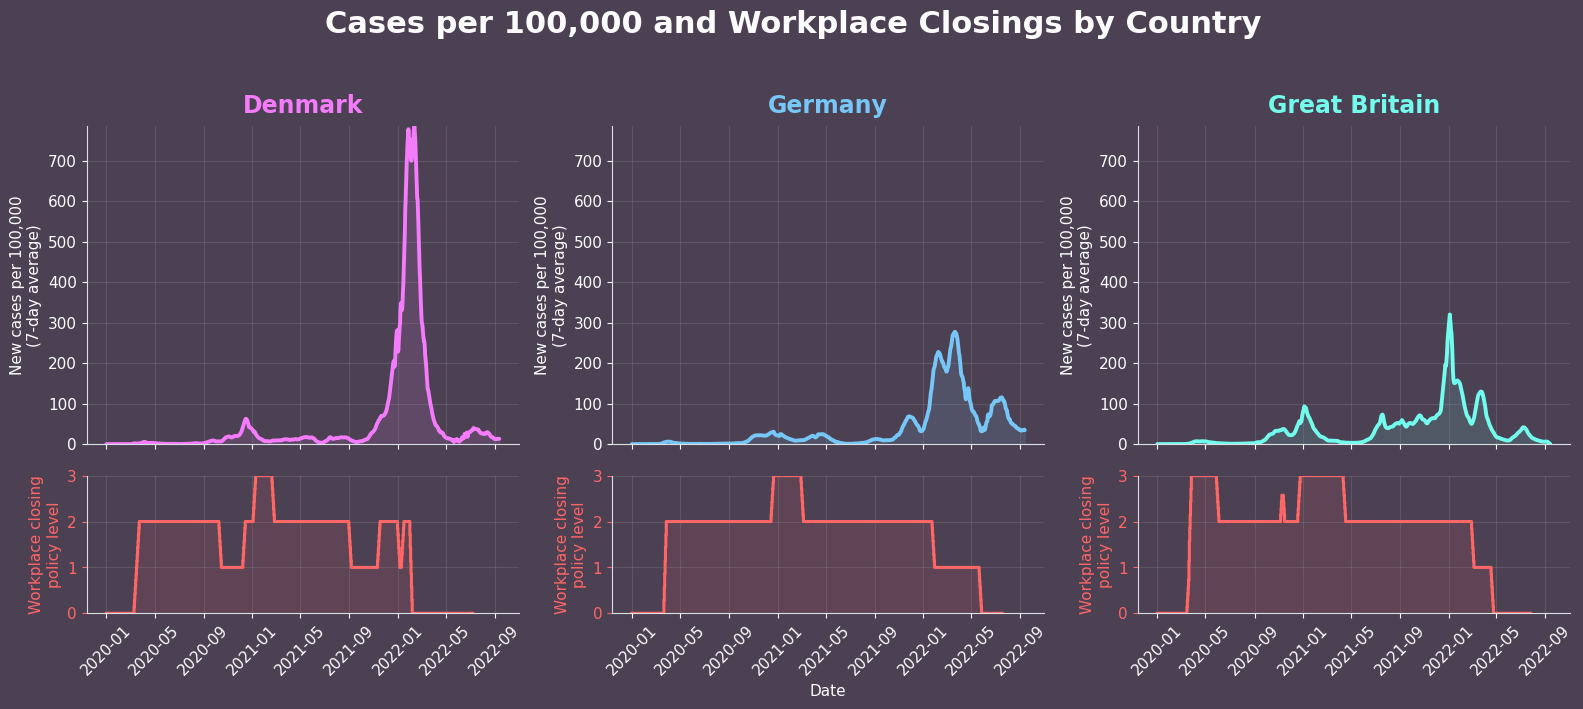

In [194]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# -----------------------------
# Colors
# -----------------------------
BG_DARK = "#4C4153"
TEXT_LIGHT = "#FCFCFC"
BORDER_SOFT = "#D9E0E4"

COUNTRY_COLORS = {
    "DK": "#F47CFB",   # Denmark
    "DE": "#76C6F8",   # Germany
    "GB": "#72FCEE",   # Great Britain
}

WORKPLACE_COLOR = "#FF6666"

selected_countries = ["DK", "DE", "GB"]

country_names = {
    "DK": "Denmark",
    "DE": "Germany",
    "GB": "Great Britain"
}

# Replace with your final chosen source if needed
population_lookup = {
    "DK": 5_900_000,
    "DE": 84_000_000,
    "GB": 67_000_000,
}

# -----------------------------
# Build epidemiology table
# -----------------------------
epi_compare = (
    epi_country[epi_country["location_key"].isin(selected_countries)]
    .copy()
    .sort_values(["location_key", "date"])
)

epi_compare["new_confirmed_7d"] = (
    epi_compare.groupby("location_key")["new_confirmed"]
    .transform(lambda s: s.rolling(7, min_periods=1).mean())
)

epi_compare["population"] = epi_compare["location_key"].map(population_lookup)
epi_compare["cases_per_100k_7d"] = (
    epi_compare["new_confirmed_7d"] / epi_compare["population"] * 100000
)

# -----------------------------
# Build government table
# workplace_closing is ordinal: 0, 1, 2, 3
# We do NOT normalize this
# -----------------------------
gov_compare = (
    gov_country[gov_country["location_key"].isin(selected_countries)]
    .copy()
    .sort_values(["location_key", "date"])
)

gov_compare["workplace_closing_7d"] = (
    gov_compare.groupby("location_key")["workplace_closing"]
    .transform(lambda s: s.rolling(7, min_periods=1).mean())
)

# -----------------------------
# Shared scales for fair comparison
# -----------------------------
cases_ymax = epi_compare["cases_per_100k_7d"].max()
workplace_ymin = 0
workplace_ymax = 3

# -----------------------------
# Matplotlib style
# -----------------------------
mpl.rcParams["figure.facecolor"] = BG_DARK
mpl.rcParams["axes.facecolor"] = BG_DARK
mpl.rcParams["savefig.facecolor"] = BG_DARK
mpl.rcParams["axes.edgecolor"] = BORDER_SOFT
mpl.rcParams["axes.labelcolor"] = TEXT_LIGHT
mpl.rcParams["xtick.color"] = TEXT_LIGHT
mpl.rcParams["ytick.color"] = TEXT_LIGHT
mpl.rcParams["text.color"] = TEXT_LIGHT
mpl.rcParams["axes.titleweight"] = "bold"
mpl.rcParams["axes.titlesize"] = 16
mpl.rcParams["axes.labelsize"] = 11
mpl.rcParams["font.size"] = 11
mpl.rcParams["grid.color"] = BORDER_SOFT
mpl.rcParams["grid.alpha"] = 0.12
mpl.rcParams["axes.grid"] = True

# -----------------------------
# Plot: 2 rows x 3 columns
# top row = cases per 100k
# bottom row = workplace closing level
# -----------------------------
fig, axes = plt.subplots(
    2, 3,
    figsize=(16, 7.2),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1.3]}
)

fig.patch.set_facecolor(BG_DARK)

for col, code in enumerate(selected_countries):
    epi_plot = epi_compare[epi_compare["location_key"] == code].sort_values("date")
    gov_plot = gov_compare[gov_compare["location_key"] == code].sort_values("date")
    c = COUNTRY_COLORS[code]

    ax_top = axes[0, col]
    ax_bottom = axes[1, col]

    # ---------- Top: cases per 100k ----------
    ax_top.set_facecolor(BG_DARK)
    ax_top.plot(
        epi_plot["date"],
        epi_plot["cases_per_100k_7d"],
        color=c,
        linewidth=2.8,
        solid_capstyle="round"
    )
    ax_top.fill_between(
        epi_plot["date"],
        epi_plot["cases_per_100k_7d"],
        color=c,
        alpha=0.12
    )

    ax_top.set_title(
        country_names[code],
        color=c,
        pad=10,
        fontsize=17,
        fontweight="bold"
    )
    ax_top.set_ylim(0, cases_ymax)
    ax_top.set_ylabel("New cases per 100,000\n(7-day average)", color=TEXT_LIGHT)

    ax_top.spines["top"].set_visible(False)
    ax_top.spines["right"].set_visible(False)
    ax_top.spines["left"].set_color(BORDER_SOFT)
    ax_top.spines["bottom"].set_color(BORDER_SOFT)
    ax_top.tick_params(axis="y", colors=TEXT_LIGHT)

    # ---------- Bottom: workplace closing ----------
    ax_bottom.set_facecolor(BG_DARK)
    ax_bottom.step(
        gov_plot["date"],
        gov_plot["workplace_closing_7d"],
        where="mid",
        color=WORKPLACE_COLOR,
        linewidth=2.2
    )
    ax_bottom.fill_between(
        gov_plot["date"],
        gov_plot["workplace_closing_7d"],
        step="mid",
        color=WORKPLACE_COLOR,
        alpha=0.10
    )

    ax_bottom.set_ylim(workplace_ymin, workplace_ymax)
    ax_bottom.set_yticks([0, 1, 2, 3])
    ax_bottom.set_ylabel("Workplace closing\npolicy level", color=WORKPLACE_COLOR)
    ax_bottom.tick_params(axis="y", colors=WORKPLACE_COLOR)
    ax_bottom.tick_params(axis="x", colors=TEXT_LIGHT, labelrotation=45)

    ax_bottom.spines["top"].set_visible(False)
    ax_bottom.spines["right"].set_visible(False)
    ax_bottom.spines["left"].set_color(BORDER_SOFT)
    ax_bottom.spines["bottom"].set_color(BORDER_SOFT)

# Only add x-axis label on bottom row center
axes[1, 1].set_xlabel("Date", color=TEXT_LIGHT)

fig.suptitle(
    "Cases per 100,000 and Workplace Closings by Country",
    fontsize=22,
    fontweight="bold",
    y=0.98,
    color=TEXT_LIGHT
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Cases per 100,000 and facial covering restrictions by country

This figure compares **Denmark, Germany, and Great Britain** using two aligned views for each country.

### Top row: new confirmed cases
The upper panels show **new confirmed COVID-19 cases per 100,000 people**, smoothed with a **7-day rolling average**.  
Using cases per 100,000 makes the countries more comparable by adjusting for population size.

### Bottom row: facial covering policy
The lower panels show the **facial covering policy level** from the Oxford Government Response dataset.  
This variable is an **ordinal policy measure**, not a population-normalized quantity, so it is shown on its own scale.

Higher values indicate stricter facial-covering requirements.

### Why this layout is fair
We do **not** place cases and facial covering restrictions on the same axis, because they measure fundamentally different things.  
Instead, we align them vertically and keep the scales consistent across countries:

- the **same case scale** is used for all countries in the top row
- the **same facial-covering scale** is used for all countries in the bottom row

This allows us to compare:
- when case waves occurred,
- when facial-covering policies became stricter or more relaxed,
- and whether changes in policy happened before, during, or after major waves.

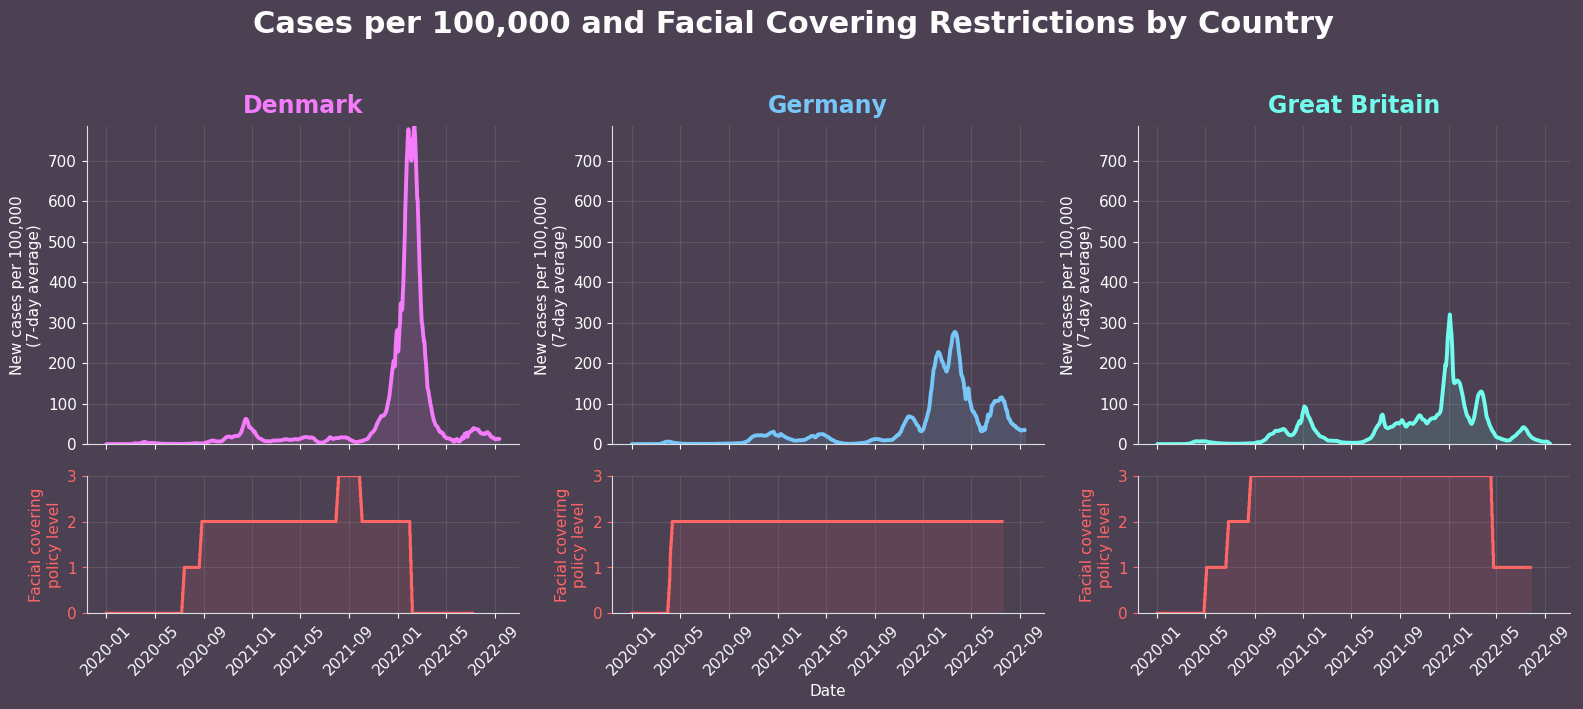

In [195]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# -----------------------------
# Colors
# -----------------------------
BG_DARK = "#4C4153"
TEXT_LIGHT = "#FCFCFC"
BORDER_SOFT = "#D9E0E4"

COUNTRY_COLORS = {
    "DK": "#F47CFB",   # Denmark
    "DE": "#76C6F8",   # Germany
    "GB": "#72FCEE",   # Great Britain
}

FACIAL_COLOR = "#FF6666"

selected_countries = ["DK", "DE", "GB"]

country_names = {
    "DK": "Denmark",
    "DE": "Germany",
    "GB": "Great Britain"
}

# Replace with your final chosen source if needed
population_lookup = {
    "DK": 5_900_000,
    "DE": 84_000_000,
    "GB": 67_000_000,
}

# -----------------------------
# Build epidemiology table
# -----------------------------
epi_compare = (
    epi_country[epi_country["location_key"].isin(selected_countries)]
    .copy()
    .sort_values(["location_key", "date"])
)

epi_compare["new_confirmed_7d"] = (
    epi_compare.groupby("location_key")["new_confirmed"]
    .transform(lambda s: s.rolling(7, min_periods=1).mean())
)

epi_compare["population"] = epi_compare["location_key"].map(population_lookup)
epi_compare["cases_per_100k_7d"] = (
    epi_compare["new_confirmed_7d"] / epi_compare["population"] * 100000
)

# -----------------------------
# Build government table
# facial_coverings is ordinal
# We do NOT normalize this
# -----------------------------
gov_compare = (
    gov_country[gov_country["location_key"].isin(selected_countries)]
    .copy()
    .sort_values(["location_key", "date"])
)

gov_compare["facial_coverings_7d"] = (
    gov_compare.groupby("location_key")["facial_coverings"]
    .transform(lambda s: s.rolling(7, min_periods=1).mean())
)

# -----------------------------
# Shared scales for fair comparison
# -----------------------------
cases_ymax = epi_compare["cases_per_100k_7d"].max()
facial_ymin = 0
facial_ymax = gov_compare["facial_coverings_7d"].max()

# -----------------------------
# Matplotlib style
# -----------------------------
mpl.rcParams["figure.facecolor"] = BG_DARK
mpl.rcParams["axes.facecolor"] = BG_DARK
mpl.rcParams["savefig.facecolor"] = BG_DARK
mpl.rcParams["axes.edgecolor"] = BORDER_SOFT
mpl.rcParams["axes.labelcolor"] = TEXT_LIGHT
mpl.rcParams["xtick.color"] = TEXT_LIGHT
mpl.rcParams["ytick.color"] = TEXT_LIGHT
mpl.rcParams["text.color"] = TEXT_LIGHT
mpl.rcParams["axes.titleweight"] = "bold"
mpl.rcParams["axes.titlesize"] = 16
mpl.rcParams["axes.labelsize"] = 11
mpl.rcParams["font.size"] = 11
mpl.rcParams["grid.color"] = BORDER_SOFT
mpl.rcParams["grid.alpha"] = 0.12
mpl.rcParams["axes.grid"] = True

# -----------------------------
# Plot: 2 rows x 3 columns
# top row = cases per 100k
# bottom row = facial coverings policy level
# -----------------------------
fig, axes = plt.subplots(
    2, 3,
    figsize=(16, 7.2),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1.3]}
)

fig.patch.set_facecolor(BG_DARK)

for col, code in enumerate(selected_countries):
    epi_plot = epi_compare[epi_compare["location_key"] == code].sort_values("date")
    gov_plot = gov_compare[gov_compare["location_key"] == code].sort_values("date")
    c = COUNTRY_COLORS[code]

    ax_top = axes[0, col]
    ax_bottom = axes[1, col]

    # ---------- Top: cases per 100k ----------
    ax_top.set_facecolor(BG_DARK)
    ax_top.plot(
        epi_plot["date"],
        epi_plot["cases_per_100k_7d"],
        color=c,
        linewidth=2.8,
        solid_capstyle="round"
    )
    ax_top.fill_between(
        epi_plot["date"],
        epi_plot["cases_per_100k_7d"],
        color=c,
        alpha=0.12
    )

    ax_top.set_title(
        country_names[code],
        color=c,
        pad=10,
        fontsize=17,
        fontweight="bold"
    )
    ax_top.set_ylim(0, cases_ymax)
    ax_top.set_ylabel("New cases per 100,000\n(7-day average)", color=TEXT_LIGHT)

    ax_top.spines["top"].set_visible(False)
    ax_top.spines["right"].set_visible(False)
    ax_top.spines["left"].set_color(BORDER_SOFT)
    ax_top.spines["bottom"].set_color(BORDER_SOFT)
    ax_top.tick_params(axis="y", colors=TEXT_LIGHT)

    # ---------- Bottom: facial coverings ----------
    ax_bottom.set_facecolor(BG_DARK)
    ax_bottom.step(
        gov_plot["date"],
        gov_plot["facial_coverings_7d"],
        where="mid",
        color=FACIAL_COLOR,
        linewidth=2.2
    )
    ax_bottom.fill_between(
        gov_plot["date"],
        gov_plot["facial_coverings_7d"],
        step="mid",
        color=FACIAL_COLOR,
        alpha=0.10
    )

    ax_bottom.set_ylim(facial_ymin, facial_ymax)
    ax_bottom.set_ylabel("Facial covering\npolicy level", color=FACIAL_COLOR)
    ax_bottom.tick_params(axis="y", colors=FACIAL_COLOR)
    ax_bottom.tick_params(axis="x", colors=TEXT_LIGHT, labelrotation=45)

    ax_bottom.spines["top"].set_visible(False)
    ax_bottom.spines["right"].set_visible(False)
    ax_bottom.spines["left"].set_color(BORDER_SOFT)
    ax_bottom.spines["bottom"].set_color(BORDER_SOFT)

# Only add x-axis label on bottom row center
axes[1, 1].set_xlabel("Date", color=TEXT_LIGHT)

fig.suptitle(
    "Cases per 100,000 and Facial Covering Restrictions by Country",
    fontsize=22,
    fontweight="bold",
    y=0.98,
    color=TEXT_LIGHT
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Cases per 100,000 and public transport closings by country

This figure compares **Denmark, Germany, and Great Britain** using two aligned views for each country.

### Top row: new confirmed cases
The upper panels show **new confirmed COVID-19 cases per 100,000 people**, smoothed with a **7-day rolling average**.  
Using cases per 100,000 makes the countries more comparable by adjusting for population size.

### Bottom row: public transport closing policy
The lower panels show the **public transport closing policy level** from the Oxford Government Response dataset.  
This variable is an **ordinal policy measure**, not a population-normalized quantity, so it is shown on its own scale.

Higher values indicate stricter public-transport closure measures.

### Why this layout is fair
We do **not** place cases and public transport closings on the same axis, because they measure fundamentally different things.  
Instead, we align them vertically and keep the scales consistent across countries:

- the **same case scale** is used for all countries in the top row
- the **same public-transport-closing scale** is used for all countries in the bottom row

This allows us to compare:
- when case waves occurred,
- when public transport restrictions became stricter or more relaxed,
- and whether changes in policy happened before, during, or after major waves.

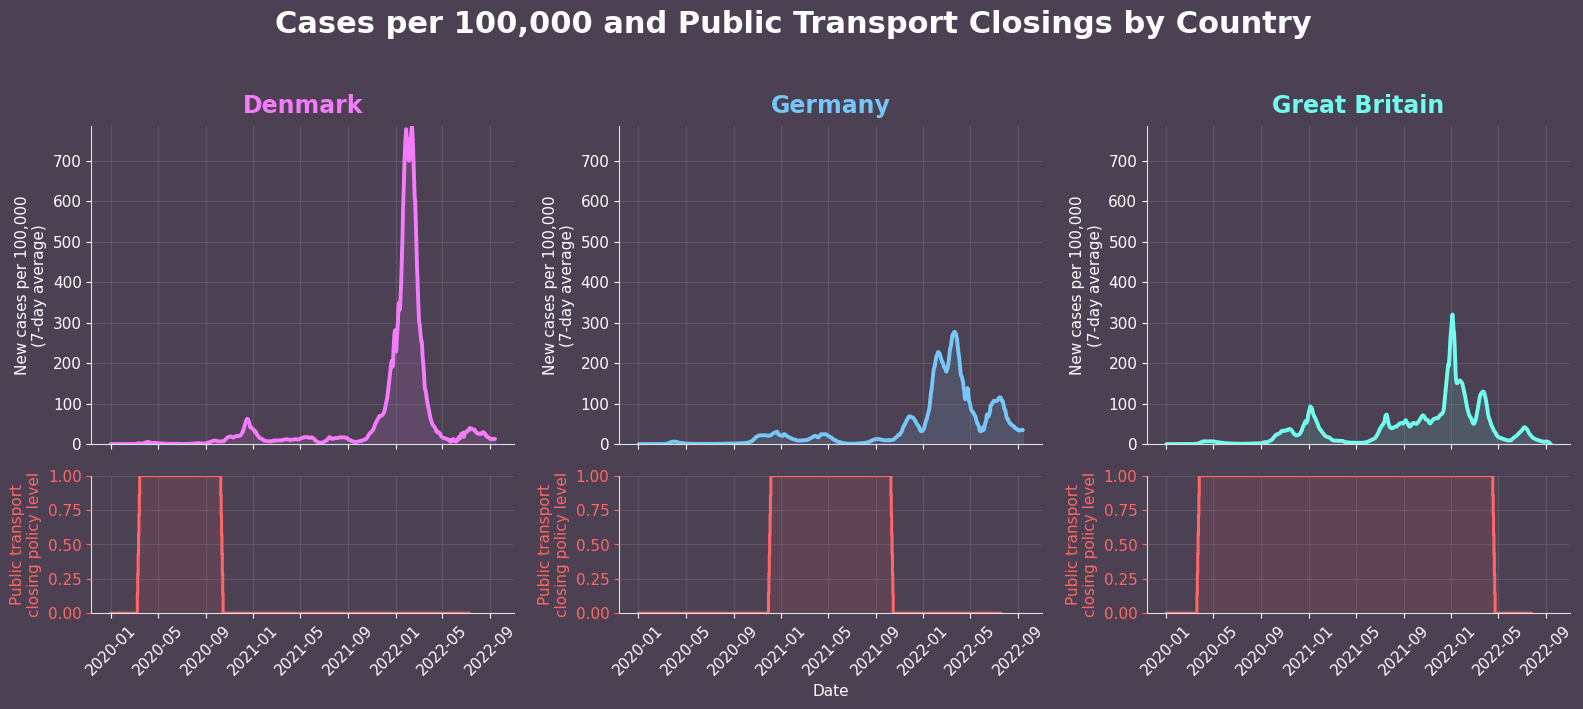

In [196]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# -----------------------------
# Colors
# -----------------------------
BG_DARK = "#4C4153"
TEXT_LIGHT = "#FCFCFC"
BORDER_SOFT = "#D9E0E4"

COUNTRY_COLORS = {
    "DK": "#F47CFB",   # Denmark
    "DE": "#76C6F8",   # Germany
    "GB": "#72FCEE",   # Great Britain
}

TRANSPORT_COLOR = "#FF6666"

selected_countries = ["DK", "DE", "GB"]

country_names = {
    "DK": "Denmark",
    "DE": "Germany",
    "GB": "Great Britain"
}

# Replace with your final chosen source if needed
population_lookup = {
    "DK": 5_900_000,
    "DE": 84_000_000,
    "GB": 67_000_000,
}

# -----------------------------
# Build epidemiology table
# -----------------------------
epi_compare = (
    epi_country[epi_country["location_key"].isin(selected_countries)]
    .copy()
    .sort_values(["location_key", "date"])
)

epi_compare["new_confirmed_7d"] = (
    epi_compare.groupby("location_key")["new_confirmed"]
    .transform(lambda s: s.rolling(7, min_periods=1).mean())
)

epi_compare["population"] = epi_compare["location_key"].map(population_lookup)
epi_compare["cases_per_100k_7d"] = (
    epi_compare["new_confirmed_7d"] / epi_compare["population"] * 100000
)

# -----------------------------
# Build government table
# public_transport_closing is ordinal
# We do NOT normalize this
# -----------------------------
gov_compare = (
    gov_country[gov_country["location_key"].isin(selected_countries)]
    .copy()
    .sort_values(["location_key", "date"])
)

gov_compare["public_transport_closing_7d"] = (
    gov_compare.groupby("location_key")["public_transport_closing"]
    .transform(lambda s: s.rolling(7, min_periods=1).mean())
)

# -----------------------------
# Shared scales for fair comparison
# -----------------------------
cases_ymax = epi_compare["cases_per_100k_7d"].max()
transport_ymin = 0
transport_ymax = gov_compare["public_transport_closing_7d"].max()

# -----------------------------
# Matplotlib style
# -----------------------------
mpl.rcParams["figure.facecolor"] = BG_DARK
mpl.rcParams["axes.facecolor"] = BG_DARK
mpl.rcParams["savefig.facecolor"] = BG_DARK
mpl.rcParams["axes.edgecolor"] = BORDER_SOFT
mpl.rcParams["axes.labelcolor"] = TEXT_LIGHT
mpl.rcParams["xtick.color"] = TEXT_LIGHT
mpl.rcParams["ytick.color"] = TEXT_LIGHT
mpl.rcParams["text.color"] = TEXT_LIGHT
mpl.rcParams["axes.titleweight"] = "bold"
mpl.rcParams["axes.titlesize"] = 16
mpl.rcParams["axes.labelsize"] = 11
mpl.rcParams["font.size"] = 11
mpl.rcParams["grid.color"] = BORDER_SOFT
mpl.rcParams["grid.alpha"] = 0.12
mpl.rcParams["axes.grid"] = True

# -----------------------------
# Plot: 2 rows x 3 columns
# top row = cases per 100k
# bottom row = public transport closing level
# -----------------------------
fig, axes = plt.subplots(
    2, 3,
    figsize=(16, 7.2),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1.3]}
)

fig.patch.set_facecolor(BG_DARK)

for col, code in enumerate(selected_countries):
    epi_plot = epi_compare[epi_compare["location_key"] == code].sort_values("date")
    gov_plot = gov_compare[gov_compare["location_key"] == code].sort_values("date")
    c = COUNTRY_COLORS[code]

    ax_top = axes[0, col]
    ax_bottom = axes[1, col]

    # ---------- Top: cases per 100k ----------
    ax_top.set_facecolor(BG_DARK)
    ax_top.plot(
        epi_plot["date"],
        epi_plot["cases_per_100k_7d"],
        color=c,
        linewidth=2.8,
        solid_capstyle="round"
    )
    ax_top.fill_between(
        epi_plot["date"],
        epi_plot["cases_per_100k_7d"],
        color=c,
        alpha=0.12
    )

    ax_top.set_title(
        country_names[code],
        color=c,
        pad=10,
        fontsize=17,
        fontweight="bold"
    )
    ax_top.set_ylim(0, cases_ymax)
    ax_top.set_ylabel("New cases per 100,000\n(7-day average)", color=TEXT_LIGHT)

    ax_top.spines["top"].set_visible(False)
    ax_top.spines["right"].set_visible(False)
    ax_top.spines["left"].set_color(BORDER_SOFT)
    ax_top.spines["bottom"].set_color(BORDER_SOFT)
    ax_top.tick_params(axis="y", colors=TEXT_LIGHT)

    # ---------- Bottom: public transport closing ----------
    ax_bottom.set_facecolor(BG_DARK)
    ax_bottom.step(
        gov_plot["date"],
        gov_plot["public_transport_closing_7d"],
        where="mid",
        color=TRANSPORT_COLOR,
        linewidth=2.2
    )
    ax_bottom.fill_between(
        gov_plot["date"],
        gov_plot["public_transport_closing_7d"],
        step="mid",
        color=TRANSPORT_COLOR,
        alpha=0.10
    )

    ax_bottom.set_ylim(transport_ymin, transport_ymax)
    ax_bottom.set_ylabel("Public transport\nclosing policy level", color=TRANSPORT_COLOR)
    ax_bottom.tick_params(axis="y", colors=TRANSPORT_COLOR)
    ax_bottom.tick_params(axis="x", colors=TEXT_LIGHT, labelrotation=45)

    ax_bottom.spines["top"].set_visible(False)
    ax_bottom.spines["right"].set_visible(False)
    ax_bottom.spines["left"].set_color(BORDER_SOFT)
    ax_bottom.spines["bottom"].set_color(BORDER_SOFT)

# Only add x-axis label on bottom row center
axes[1, 1].set_xlabel("Date", color=TEXT_LIGHT)

fig.suptitle(
    "Cases per 100,000 and Public Transport Closings by Country",
    fontsize=22,
    fontweight="bold",
    y=0.98,
    color=TEXT_LIGHT
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Cases per 100,000 and testing policy by country

This figure compares **Denmark, Germany, and Great Britain** using two aligned views for each country.

### Top row: new confirmed cases
The upper panels show **new confirmed COVID-19 cases per 100,000 people**, smoothed with a **7-day rolling average**.  
Using cases per 100,000 makes the countries more comparable by adjusting for population size.

### Bottom row: testing policy
The lower panels show the **testing policy level** from the Oxford Government Response dataset.  
This variable is an **ordinal policy measure**, not a population-normalized quantity, so it is shown on its own scale.

Higher values indicate broader or more intensive testing policy.

### Why this layout is fair
We do **not** place cases and testing policy on the same axis, because they measure fundamentally different things.  
Instead, we align them vertically and keep the scales consistent across countries:

- the **same case scale** is used for all countries in the top row
- the **same testing-policy scale** is used for all countries in the bottom row

This allows us to compare:
- when case waves occurred,
- when testing policy became broader or more restrictive,
- and whether changes in testing policy happened before, during, or after major waves.

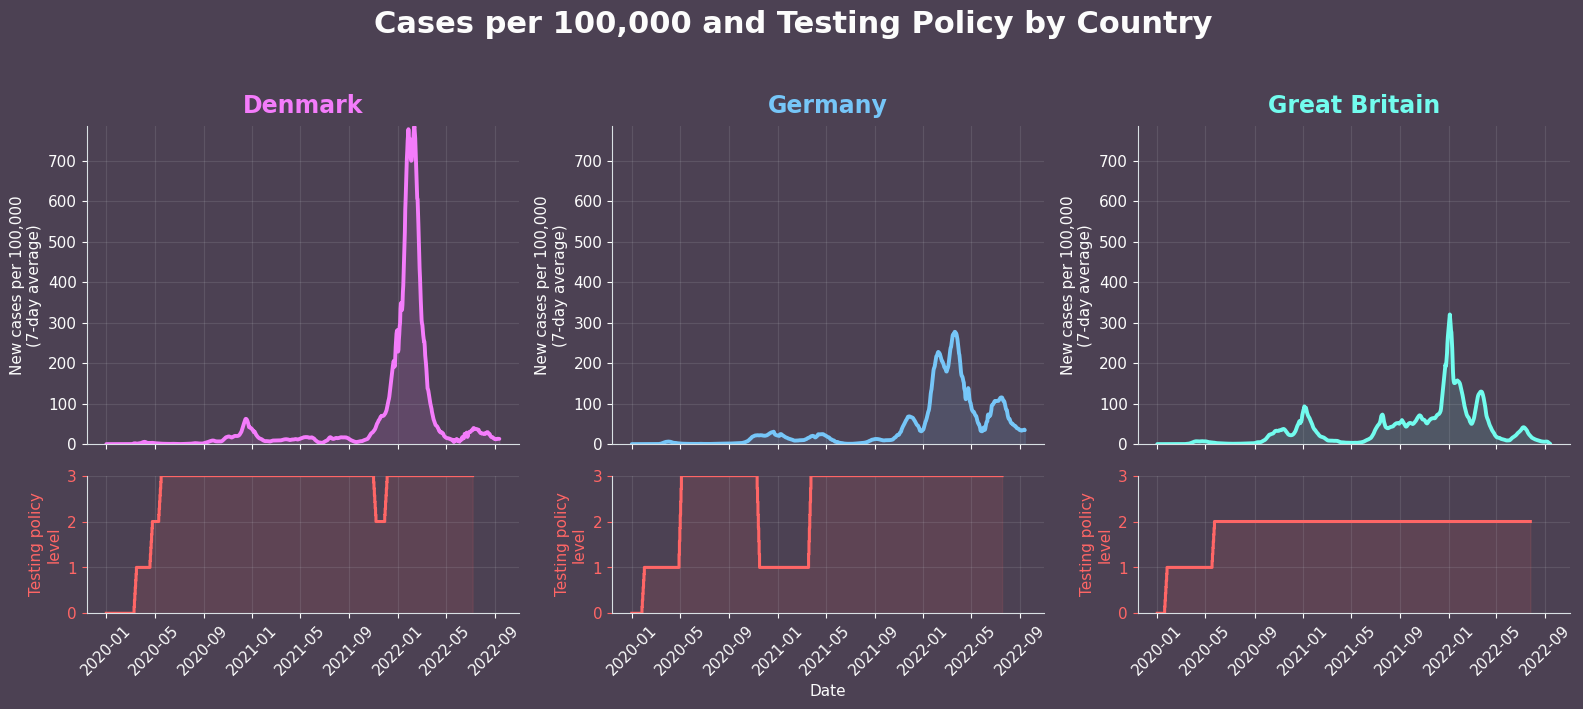

In [197]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# -----------------------------
# Colors
# -----------------------------
BG_DARK = "#4C4153"
TEXT_LIGHT = "#FCFCFC"
BORDER_SOFT = "#D9E0E4"

COUNTRY_COLORS = {
    "DK": "#F47CFB",   # Denmark
    "DE": "#76C6F8",   # Germany
    "GB": "#72FCEE",   # Great Britain
}

TESTING_COLOR = "#FF6666"

selected_countries = ["DK", "DE", "GB"]

country_names = {
    "DK": "Denmark",
    "DE": "Germany",
    "GB": "Great Britain"
}

# Replace with your final chosen source if needed
population_lookup = {
    "DK": 5_900_000,
    "DE": 84_000_000,
    "GB": 67_000_000,
}

# -----------------------------
# Build epidemiology table
# -----------------------------
epi_compare = (
    epi_country[epi_country["location_key"].isin(selected_countries)]
    .copy()
    .sort_values(["location_key", "date"])
)

epi_compare["new_confirmed_7d"] = (
    epi_compare.groupby("location_key")["new_confirmed"]
    .transform(lambda s: s.rolling(7, min_periods=1).mean())
)

epi_compare["population"] = epi_compare["location_key"].map(population_lookup)
epi_compare["cases_per_100k_7d"] = (
    epi_compare["new_confirmed_7d"] / epi_compare["population"] * 100000
)

# -----------------------------
# Build government table
# testing_policy is ordinal
# We do NOT normalize this
# -----------------------------
gov_compare = (
    gov_country[gov_country["location_key"].isin(selected_countries)]
    .copy()
    .sort_values(["location_key", "date"])
)

gov_compare["testing_policy_7d"] = (
    gov_compare.groupby("location_key")["testing_policy"]
    .transform(lambda s: s.rolling(7, min_periods=1).mean())
)

# -----------------------------
# Shared scales for fair comparison
# -----------------------------
cases_ymax = epi_compare["cases_per_100k_7d"].max()
testing_ymin = 0
testing_ymax = gov_compare["testing_policy_7d"].max()

# -----------------------------
# Matplotlib style
# -----------------------------
mpl.rcParams["figure.facecolor"] = BG_DARK
mpl.rcParams["axes.facecolor"] = BG_DARK
mpl.rcParams["savefig.facecolor"] = BG_DARK
mpl.rcParams["axes.edgecolor"] = BORDER_SOFT
mpl.rcParams["axes.labelcolor"] = TEXT_LIGHT
mpl.rcParams["xtick.color"] = TEXT_LIGHT
mpl.rcParams["ytick.color"] = TEXT_LIGHT
mpl.rcParams["text.color"] = TEXT_LIGHT
mpl.rcParams["axes.titleweight"] = "bold"
mpl.rcParams["axes.titlesize"] = 16
mpl.rcParams["axes.labelsize"] = 11
mpl.rcParams["font.size"] = 11
mpl.rcParams["grid.color"] = BORDER_SOFT
mpl.rcParams["grid.alpha"] = 0.12
mpl.rcParams["axes.grid"] = True

# -----------------------------
# Plot: 2 rows x 3 columns
# top row = cases per 100k
# bottom row = testing policy level
# -----------------------------
fig, axes = plt.subplots(
    2, 3,
    figsize=(16, 7.2),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1.3]}
)

fig.patch.set_facecolor(BG_DARK)

for col, code in enumerate(selected_countries):
    epi_plot = epi_compare[epi_compare["location_key"] == code].sort_values("date")
    gov_plot = gov_compare[gov_compare["location_key"] == code].sort_values("date")
    c = COUNTRY_COLORS[code]

    ax_top = axes[0, col]
    ax_bottom = axes[1, col]

    # ---------- Top: cases per 100k ----------
    ax_top.set_facecolor(BG_DARK)
    ax_top.plot(
        epi_plot["date"],
        epi_plot["cases_per_100k_7d"],
        color=c,
        linewidth=2.8,
        solid_capstyle="round"
    )
    ax_top.fill_between(
        epi_plot["date"],
        epi_plot["cases_per_100k_7d"],
        color=c,
        alpha=0.12
    )

    ax_top.set_title(
        country_names[code],
        color=c,
        pad=10,
        fontsize=17,
        fontweight="bold"
    )
    ax_top.set_ylim(0, cases_ymax)
    ax_top.set_ylabel("New cases per 100,000\n(7-day average)", color=TEXT_LIGHT)

    ax_top.spines["top"].set_visible(False)
    ax_top.spines["right"].set_visible(False)
    ax_top.spines["left"].set_color(BORDER_SOFT)
    ax_top.spines["bottom"].set_color(BORDER_SOFT)
    ax_top.tick_params(axis="y", colors=TEXT_LIGHT)

    # ---------- Bottom: testing policy ----------
    ax_bottom.set_facecolor(BG_DARK)
    ax_bottom.step(
        gov_plot["date"],
        gov_plot["testing_policy_7d"],
        where="mid",
        color=TESTING_COLOR,
        linewidth=2.2
    )
    ax_bottom.fill_between(
        gov_plot["date"],
        gov_plot["testing_policy_7d"],
        step="mid",
        color=TESTING_COLOR,
        alpha=0.10
    )

    ax_bottom.set_ylim(testing_ymin, testing_ymax)
    ax_bottom.set_ylabel("Testing policy\nlevel", color=TESTING_COLOR)
    ax_bottom.tick_params(axis="y", colors=TESTING_COLOR)
    ax_bottom.tick_params(axis="x", colors=TEXT_LIGHT, labelrotation=45)

    ax_bottom.spines["top"].set_visible(False)
    ax_bottom.spines["right"].set_visible(False)
    ax_bottom.spines["left"].set_color(BORDER_SOFT)
    ax_bottom.spines["bottom"].set_color(BORDER_SOFT)

# Only add x-axis label on bottom row center
axes[1, 1].set_xlabel("Date", color=TEXT_LIGHT)

fig.suptitle(
    "Cases per 100,000 and Testing Policy by Country",
    fontsize=22,
    fontweight="bold",
    y=0.98,
    color=TEXT_LIGHT
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Cases per 100,000 and stay-at-home requirements by country

This figure compares **Denmark, Germany, and Great Britain** using two aligned views for each country.

### Top row: new confirmed cases
The upper panels show **new confirmed COVID-19 cases per 100,000 people**, smoothed with a **7-day rolling average**.  
Using cases per 100,000 makes the countries more comparable by adjusting for population size.

### Bottom row: stay-at-home requirements
The lower panels show the **stay-at-home requirements policy level** from the Oxford Government Response dataset.  
This variable is an **ordinal policy measure**, not a population-normalized quantity, so it is shown on its own scale.

Higher values indicate stricter stay-at-home requirements.

### Why this layout is fair
We do **not** place cases and stay-at-home requirements on the same axis, because they measure fundamentally different things.  
Instead, we align them vertically and keep the scales consistent across countries:

- the **same case scale** is used for all countries in the top row
- the **same stay-at-home scale** is used for all countries in the bottom row

This allows us to compare:
- when case waves occurred,
- when stay-at-home requirements became stricter or more relaxed,
- and whether changes in policy happened before, during, or after major waves.

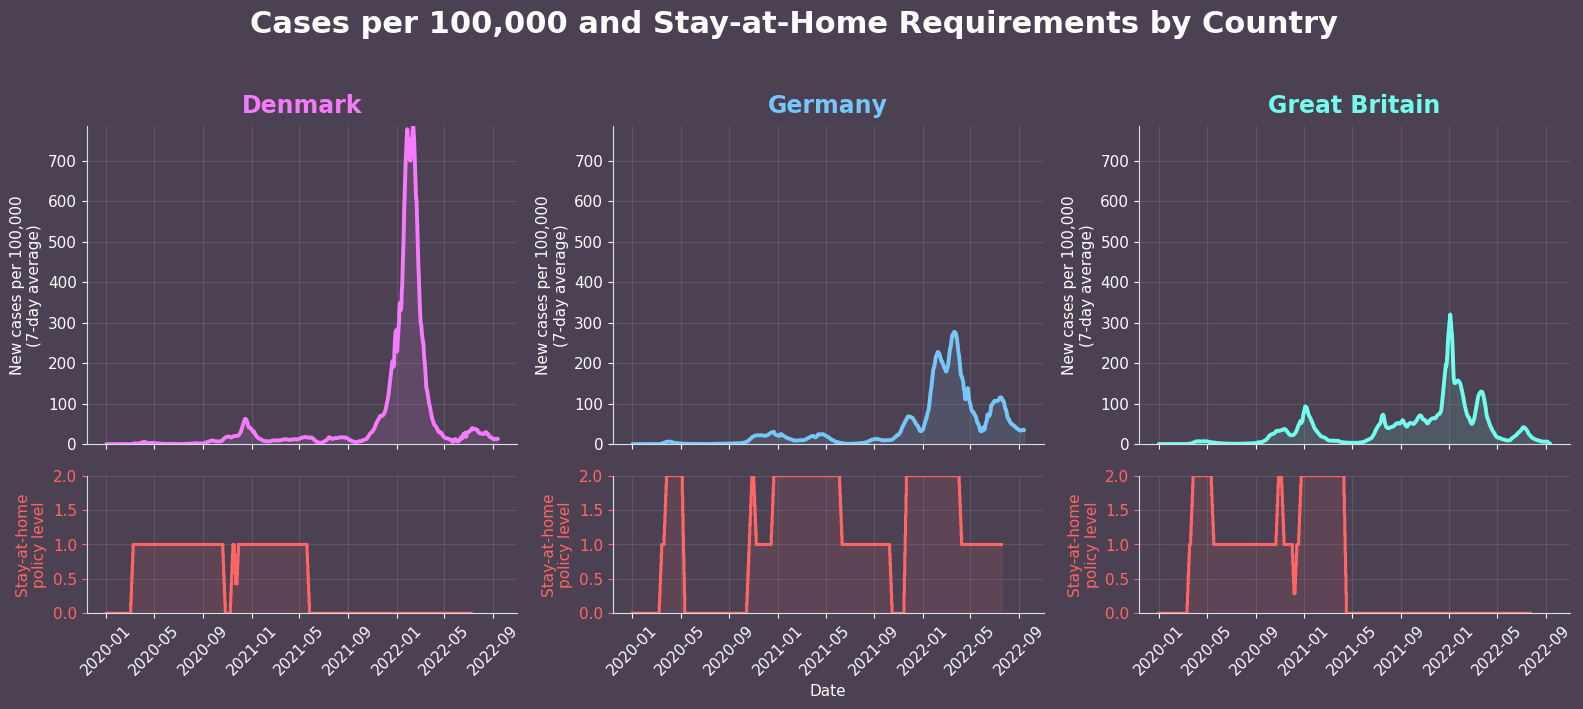

In [198]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# -----------------------------
# Colors
# -----------------------------
BG_DARK = "#4C4153"
TEXT_LIGHT = "#FCFCFC"
BORDER_SOFT = "#D9E0E4"

COUNTRY_COLORS = {
    "DK": "#F47CFB",   # Denmark
    "DE": "#76C6F8",   # Germany
    "GB": "#72FCEE",   # Great Britain
}

STAY_HOME_COLOR = "#FF6666"

selected_countries = ["DK", "DE", "GB"]

country_names = {
    "DK": "Denmark",
    "DE": "Germany",
    "GB": "Great Britain"
}

# Replace with your final chosen source if needed
population_lookup = {
    "DK": 5_900_000,
    "DE": 84_000_000,
    "GB": 67_000_000,
}

# -----------------------------
# Build epidemiology table
# -----------------------------
epi_compare = (
    epi_country[epi_country["location_key"].isin(selected_countries)]
    .copy()
    .sort_values(["location_key", "date"])
)

epi_compare["new_confirmed_7d"] = (
    epi_compare.groupby("location_key")["new_confirmed"]
    .transform(lambda s: s.rolling(7, min_periods=1).mean())
)

epi_compare["population"] = epi_compare["location_key"].map(population_lookup)
epi_compare["cases_per_100k_7d"] = (
    epi_compare["new_confirmed_7d"] / epi_compare["population"] * 100000
)

# -----------------------------
# Build government table
# stay_at_home_requirements is ordinal
# We do NOT normalize this
# -----------------------------
gov_compare = (
    gov_country[gov_country["location_key"].isin(selected_countries)]
    .copy()
    .sort_values(["location_key", "date"])
)

gov_compare["stay_home_7d"] = (
    gov_compare.groupby("location_key")["stay_at_home_requirements"]
    .transform(lambda s: s.rolling(7, min_periods=1).mean())
)

# -----------------------------
# Shared scales for fair comparison
# -----------------------------
cases_ymax = epi_compare["cases_per_100k_7d"].max()
stay_home_ymin = 0
stay_home_ymax = gov_compare["stay_home_7d"].max()

# -----------------------------
# Matplotlib style
# -----------------------------
mpl.rcParams["figure.facecolor"] = BG_DARK
mpl.rcParams["axes.facecolor"] = BG_DARK
mpl.rcParams["savefig.facecolor"] = BG_DARK
mpl.rcParams["axes.edgecolor"] = BORDER_SOFT
mpl.rcParams["axes.labelcolor"] = TEXT_LIGHT
mpl.rcParams["xtick.color"] = TEXT_LIGHT
mpl.rcParams["ytick.color"] = TEXT_LIGHT
mpl.rcParams["text.color"] = TEXT_LIGHT
mpl.rcParams["axes.titleweight"] = "bold"
mpl.rcParams["axes.titlesize"] = 16
mpl.rcParams["axes.labelsize"] = 11
mpl.rcParams["font.size"] = 11
mpl.rcParams["grid.color"] = BORDER_SOFT
mpl.rcParams["grid.alpha"] = 0.12
mpl.rcParams["axes.grid"] = True

# -----------------------------
# Plot: 2 rows x 3 columns
# top row = cases per 100k
# bottom row = stay-at-home requirements level
# -----------------------------
fig, axes = plt.subplots(
    2, 3,
    figsize=(16, 7.2),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1.3]}
)

fig.patch.set_facecolor(BG_DARK)

for col, code in enumerate(selected_countries):
    epi_plot = epi_compare[epi_compare["location_key"] == code].sort_values("date")
    gov_plot = gov_compare[gov_compare["location_key"] == code].sort_values("date")
    c = COUNTRY_COLORS[code]

    ax_top = axes[0, col]
    ax_bottom = axes[1, col]

    # ---------- Top: cases per 100k ----------
    ax_top.set_facecolor(BG_DARK)
    ax_top.plot(
        epi_plot["date"],
        epi_plot["cases_per_100k_7d"],
        color=c,
        linewidth=2.8,
        solid_capstyle="round"
    )
    ax_top.fill_between(
        epi_plot["date"],
        epi_plot["cases_per_100k_7d"],
        color=c,
        alpha=0.12
    )

    ax_top.set_title(
        country_names[code],
        color=c,
        pad=10,
        fontsize=17,
        fontweight="bold"
    )
    ax_top.set_ylim(0, cases_ymax)
    ax_top.set_ylabel("New cases per 100,000\n(7-day average)", color=TEXT_LIGHT)

    ax_top.spines["top"].set_visible(False)
    ax_top.spines["right"].set_visible(False)
    ax_top.spines["left"].set_color(BORDER_SOFT)
    ax_top.spines["bottom"].set_color(BORDER_SOFT)
    ax_top.tick_params(axis="y", colors=TEXT_LIGHT)

    # ---------- Bottom: stay-at-home requirements ----------
    ax_bottom.set_facecolor(BG_DARK)
    ax_bottom.step(
        gov_plot["date"],
        gov_plot["stay_home_7d"],
        where="mid",
        color=STAY_HOME_COLOR,
        linewidth=2.2
    )
    ax_bottom.fill_between(
        gov_plot["date"],
        gov_plot["stay_home_7d"],
        step="mid",
        color=STAY_HOME_COLOR,
        alpha=0.10
    )

    ax_bottom.set_ylim(stay_home_ymin, stay_home_ymax)
    ax_bottom.set_ylabel("Stay-at-home\npolicy level", color=STAY_HOME_COLOR)
    ax_bottom.tick_params(axis="y", colors=STAY_HOME_COLOR)
    ax_bottom.tick_params(axis="x", colors=TEXT_LIGHT, labelrotation=45)

    ax_bottom.spines["top"].set_visible(False)
    ax_bottom.spines["right"].set_visible(False)
    ax_bottom.spines["left"].set_color(BORDER_SOFT)
    ax_bottom.spines["bottom"].set_color(BORDER_SOFT)

# Only add x-axis label on bottom row center
axes[1, 1].set_xlabel("Date", color=TEXT_LIGHT)

fig.suptitle(
    "Cases per 100,000 and Stay-at-Home Requirements by Country",
    fontsize=22,
    fontweight="bold",
    y=0.98,
    color=TEXT_LIGHT
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()